# StudySense — AI-Powered Student Performance & Study Recommendation System
## Machine Learning Component: Performance Prediction & Explainable Recommendations

**Project:** StudySense (Android application for student academic self-monitoring)
**ML Notebook:** `StudySense_ML_Analysis_and_Modeling.ipynb`
**Author role:** ML / Data Science engineering component of a B.Tech capstone project

---

### Objective

This notebook builds, evaluates, and documents the machine-learning component that will
eventually be integrated (via a serialized model + defined feature schema) into the
StudySense Android application. The application collects student behavioural and
contextual data locally (Room Database) and is expected to surface:

- A performance prediction (with honest uncertainty, not a false sense of certainty)
- A transparent, rule-based risk categorisation derived from that prediction
- Explainable, rule-based study recommendations

### Dataset

**Students Performance Dataset** (Rabie El Kharoua) — 2,392 students, 15 columns,
including demographic, behavioural, and academic-support features, a continuous
`GPA` value, and a categorical `GradeClass` (0–4).

Source: https://www.kaggle.com/datasets/rabieelkharoua/students-performance-dataset

### ML Tasks

- **Task A (primary): Multiclass classification** — predict `GradeClass` (5 classes) from
  behavioural/contextual features.
- **Task B (secondary, exploratory): Regression** — predict `GPA` from the same feature pool,
  investigated to determine whether it adds value beyond classification.

### Technologies

Python, NumPy, Pandas, Matplotlib, Seaborn, Scikit-learn, SciPy, imbalanced-learn (for
class-imbalance experiments), Joblib.

### High-level workflow

```
Raw CSV
   -> Data quality audit & data dictionary
   -> EDA
   -> Data-leakage & feature-availability analysis   <-- decides what Android may use as input
   -> Cleaning or feature engineering
   -> Train/test split (stratified) + CV
   -> Preprocessing pipeline (ColumnTransformer)
   -> Baseline models -> class-imbalance handling -> tuned models
   -> Evaluation (imbalance-aware metrics) + explainability
   -> Risk mapping + rule-based recommendation layer (kept separate from the ML model)
   -> Serialized pipeline + metadata + documented Android input schema
```

All reported numbers in this notebook are produced by the code that is actually executed
below — nothing here is a hypothetical or hand-typed result.


## 1. Environment and Imports

**What:** Import the libraries used throughout the notebook.

**Why:** StudySense's ML pipeline only needs a standard, well-supported scientific-Python
stack. Keeping imports minimal keeps the eventual Android-deployment conversion step
simpler and keeps the notebook easy to audit.

**Expected outcome:** All required libraries import cleanly with their versions printed,
so the notebook run is reproducible and auditable.


In [1]:

import warnings
import json
import platform
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import sklearn
import joblib

# We do not blanket-suppress every warning: only cosmetic, non-actionable
# FutureWarning/UserWarning noise from plotting libraries is filtered so that
# genuine modelling warnings (e.g. convergence warnings) remain visible.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

print("Python     :", platform.python_version())
print("NumPy      :", np.__version__)
print("Pandas     :", pd.__version__)
print("Matplotlib :", matplotlib.__version__)
print("Seaborn    :", sns.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Joblib     :", joblib.__version__)


Python     : 3.14.6
NumPy      : 2.5.3
Pandas     : 3.0.5
Matplotlib : 3.11.1
Seaborn    : 0.13.2
Scikit-learn: 1.9.0
Joblib     : 1.6.0


## 2. Reproducibility Configuration

**What:** Centralise the random seed, dataset path, output directories, and split/CV
parameters in one place.

**Why:** Every later section (splitting, tuning, evaluation) must reference the same
constants so the whole notebook is reproducible end-to-end and none of the results are
tuning artefacts of an ad-hoc seed choice.

**Expected outcome:** A single `CONFIG` object that the rest of the notebook consults,
plus created (empty, at this point) output folders.


In [8]:

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

CONFIG = {
    "random_seed": RANDOM_SEED,
    "data_path": Path("../data/Student_performance_data.csv"),
    "models_dir": Path("../models"),
    "outputs_dir": Path("../outputs"),
    "figures_dir": Path("../outputs/figures"),
    "metrics_dir": Path("../outputs/metrics"),
    "predictions_dir": Path("../outputs/predictions"),
    "reports_dir": Path("../outputs/reports"),
    "test_size": 0.20,
    "cv_folds": 5,
}

for key in ("models_dir", "outputs_dir", "figures_dir", "metrics_dir",
            "predictions_dir", "reports_dir"):
    CONFIG[key].mkdir(parents=True, exist_ok=True)

def savefig(name):
    # Save the current matplotlib figure into outputs/figures with a tight layout.
    plt.tight_layout()
    plt.savefig(CONFIG["figures_dir"] / f"{name}.png", bbox_inches="tight")

print("Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


Configuration:
  random_seed: 42
  data_path: ..\data\Student_performance_data.csv
  models_dir: ..\models
  outputs_dir: ..\outputs
  figures_dir: ..\outputs\figures
  metrics_dir: ..\outputs\metrics
  predictions_dir: ..\outputs\predictions
  reports_dir: ..\outputs\reports
  test_size: 0.2
  cv_folds: 5


## 3. Data Loading

**What:** Load the StudySense student-performance CSV from a configurable path and
perform a first structural inspection.

**Why:** The dataset is the foundation of the entire pipeline. Before any cleaning or
modelling, we must confirm the file exists, has the expected shape, and load without
silent parsing errors.

**Expected outcome:** A DataFrame with 2,392 rows and 15 columns, matching the schema
documented for this dataset. The notebook fails loudly (not silently) if the file is
missing or the schema is unexpected.


In [9]:

if not CONFIG["data_path"].exists():
    raise FileNotFoundError(
        f"Expected dataset at '{CONFIG['data_path'].resolve()}'. "
        "Place 'Student_performance_data.csv' next to this notebook, or update "
        "CONFIG['data_path']."
    )

df_raw = pd.read_csv(CONFIG["data_path"])

EXPECTED_COLUMNS = [
    "StudentID", "Age", "Gender", "Ethnicity", "ParentalEducation",
    "StudyTimeWeekly", "Absences", "Tutoring", "ParentalSupport",
    "Extracurricular", "Sports", "Music", "Volunteering", "GPA", "GradeClass",
]
missing_cols = set(EXPECTED_COLUMNS) - set(df_raw.columns)
if missing_cols:
    raise ValueError(f"Dataset is missing expected columns: {missing_cols}")

print("Shape:", df_raw.shape)
print("\nColumn dtypes:")
print(df_raw.dtypes)


Shape: (2392, 15)

Column dtypes:
StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass             int64
dtype: object


In [10]:

display(df_raw.head())


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4


In [11]:

display(df_raw.tail())


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1
2391,3392,16,1,0,2,17.819907,13,0,2,0,0,0,1,2.140014,1


## 4. Data Quality Audit

**What:** Programmatically audit missing values, duplicate rows/IDs, constant columns,
numeric ranges, and category cardinalities.

**Why:** Every claim about this dataset in the SRS/prompt ("no missing values", "Age is
15–18", etc.) must be *verified* on the actual file rather than assumed — assumptions
that turn out to be wrong would silently corrupt later modelling decisions.

**Expected outcome:** A single audit table summarising every column, plus explicit
duplicate/constant-column checks, so any data-quality problem is visible before we
proceed.


In [14]:

def audit_table(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in frame.columns:
        s = frame[col]
        is_numeric = pd.api.types.is_numeric_dtype(s)
        rows.append({
            "Column": col,
            "Data Type": str(s.dtype),
            "Missing": int(s.isna().sum()),
            "Missing %": round(100 * s.isna().mean(), 2),
            "Unique": int(s.nunique()),
            "Min": round(float(s.min()), 3) if is_numeric else "-",
            "Max": round(float(s.max()), 3) if is_numeric else "-",
            "Constant column": bool(s.nunique() <= 1),
        })
    return pd.DataFrame(rows)

quality_report = audit_table(df_raw)
display(quality_report)

n_dupe_rows = int(df_raw.duplicated().sum())
n_dupe_ids = int(df_raw["StudentID"].duplicated().sum())
n_unique_ids = df_raw["StudentID"].nunique()

print(f"Fully duplicated rows: {n_dupe_rows}")
print(f"Duplicate StudentID values: {n_dupe_ids}")
print(f"Unique StudentID count: {n_unique_ids} (expected {len(df_raw)})")

assert n_unique_ids == len(df_raw), "StudentID is not a clean 1-row-per-student identifier!"


,Column,Data Type,Missing,Missing %,Unique,Min,Max,Constant column
0,StudentID,int64,0,0.0,2392,1001.000,3392.000,False
1,Age,int64,0,0.0,4,15.000,18.000,False
2,Gender,int64,0,0.0,2,0.000,1.000,False
3,Ethnicity,int64,0,0.0,4,0.000,3.000,False
4,ParentalEducation,int64,0,0.0,5,0.000,4.000,False
5,StudyTimeWeekly,float64,0,0.0,2392,0.001,19.978,False
6,Absences,int64,0,0.0,30,0.000,29.000,False
7,Tutoring,int64,0,0.0,2,0.000,1.000,False
8,ParentalSupport,int64,0,0.0,5,0.000,4.000,False
9,Extracurricular,int64,0,0.0,2,0.000,1.000,False


Fully duplicated rows: 0
Duplicate StudentID values: 0
Unique StudentID count: 2392 (expected 2392)


In [15]:

# Sanity-check the specific numeric ranges referenced in the project brief, rather
# than trusting them blindly.
range_checks = {
    "Age": (15, 18),
    "StudyTimeWeekly": (0, 20),
    "Absences": (0, 29),
    "GPA": (0, 4),
}
for col, (lo, hi) in range_checks.items():
    actual_lo, actual_hi = df_raw[col].min(), df_raw[col].max()
    status = "OK" if (actual_lo >= lo - 1e-6) and (actual_hi <= hi + 1e-6) else "MISMATCH"
    print(f"{col:18s} expected~[{lo}, {hi}]   actual=[{actual_lo:.3f}, {actual_hi:.3f}]  -> {status}")

binary_cols = ["Gender", "Tutoring", "Extracurricular", "Sports", "Music", "Volunteering"]
for col in binary_cols:
    vals = sorted(df_raw[col].unique().tolist())
    print(f"{col:18s} unique values = {vals}")

ordinal_like_cols = ["Ethnicity", "ParentalEducation", "ParentalSupport", "GradeClass"]
for col in ordinal_like_cols:
    vals = sorted(df_raw[col].unique().tolist())
    print(f"{col:18s} unique values = {vals}")


Age                expected~[15, 18]   actual=[15.000, 18.000]  -> OK
StudyTimeWeekly    expected~[0, 20]   actual=[0.001, 19.978]  -> OK
Absences           expected~[0, 29]   actual=[0.000, 29.000]  -> OK
GPA                expected~[0, 4]   actual=[0.000, 4.000]  -> OK
Gender             unique values = [0, 1]
Tutoring           unique values = [0, 1]
Extracurricular    unique values = [0, 1]
Sports             unique values = [0, 1]
Music              unique values = [0, 1]
Volunteering       unique values = [0, 1]
Ethnicity          unique values = [0, 1, 2, 3]
ParentalEducation  unique values = [0, 1, 2, 3, 4]
ParentalSupport    unique values = [0, 1, 2, 3, 4]
GradeClass         unique values = [0, 1, 2, 3, 4]


## 5. Data Dictionary

**What:** Document every column's meaning, type, and modelling role.

**Why:** The encoded integer columns (`Gender`, `Ethnicity`, `ParentalEducation`,
`ParentalSupport`) are meaningless without a mapping, and several columns (`StudentID`,
`GPA` relative to `GradeClass`) must be flagged now as *non-features* so later sections
don't accidentally reuse them without justification.

We only state category mappings that are supported by the dataset's public
documentation (Kaggle dataset card by Rabie El Kharoua). Where the source documentation
does not specify a mapping (e.g. which integer corresponds to which ethnicity label),
we do not invent one — the column is still usable by the model as a nominal/ordinal
code, but we avoid fabricating human-readable labels that the source does not provide.

**Expected outcome:** A markdown table serving as the single reference for every
column's role in later modelling.



| Feature | Meaning | Data Type | Role | Notes |
|---|---|---|---|---|
| `StudentID` | Unique student identifier | Integer | Identifier | **Excluded from modelling** — no predictive meaning, would leak row identity |
| `Age` | Student age in years (15–18) | Integer | Numerical feature | Narrow range; treated as numeric |
| `Gender` | Encoded gender (2 categories) | Integer (binary code) | Binary / nominal feature | Per dataset documentation: 0 = Male, 1 = Female |
| `Ethnicity` | Encoded ethnicity (4 categories) | Integer (nominal code) | Nominal feature | Per dataset documentation: 0 = Caucasian, 1 = African American, 2 = Asian, 3 = Other. Treated as nominal (one-hot), not ordinal |
| `ParentalEducation` | Encoded parental education level (5 categories) | Integer (ordinal code) | Ordinal feature | Per dataset documentation: 0 = None, 1 = High School, 2 = Some College, 3 = Bachelor's, 4 = Higher — genuinely ordered |
| `StudyTimeWeekly` | Hours studied per week | Float (~0–20) | Numerical feature | Continuous |
| `Absences` | Number of absences (0–29) | Integer | Numerical feature | Continuous count |
| `Tutoring` | Receives tutoring | Integer (binary) | Binary feature | 0 = No, 1 = Yes |
| `ParentalSupport` | Encoded level of parental support (5 categories) | Integer (ordinal code) | Ordinal feature | Per dataset documentation: 0 = None … 4 = Very High — genuinely ordered |
| `Extracurricular` | Participates in extracurricular activities | Integer (binary) | Binary feature | 0 = No, 1 = Yes |
| `Sports` | Participates in sports | Integer (binary) | Binary feature | 0 = No, 1 = Yes |
| `Music` | Participates in music activities | Integer (binary) | Binary feature | 0 = No, 1 = Yes |
| `Volunteering` | Participates in volunteering | Integer (binary) | Binary feature | 0 = No, 1 = Yes |
| `GPA` | Continuous grade point average (0–4) | Float | **Secondary target** (Task B); **potential leakage feature for Task A** | See Section 6 — strongly related to `GradeClass` |
| `GradeClass` | Categorical performance band (0=best … 4=lowest) | Integer (5 classes) | **Primary target** (Task A) | See Section 6 — appears to be constructed from `GPA` thresholds |



## 6. Exploratory Data Analysis — Dataset Overview

**What:** Visualise the distributions of the target variables and the main numeric
features (GPA, study time, absences, age) before looking at relationships between them.

**Why:** Understanding each variable in isolation is a prerequisite for interpreting any
bivariate analysis correctly, and for catching skew, imbalance, or unusual value
concentrations early.

**Expected outcome:** A clear picture of class imbalance in `GradeClass`, the shape of
the `GPA` distribution, and the spread of `StudyTimeWeekly`, `Absences`, and `Age`.


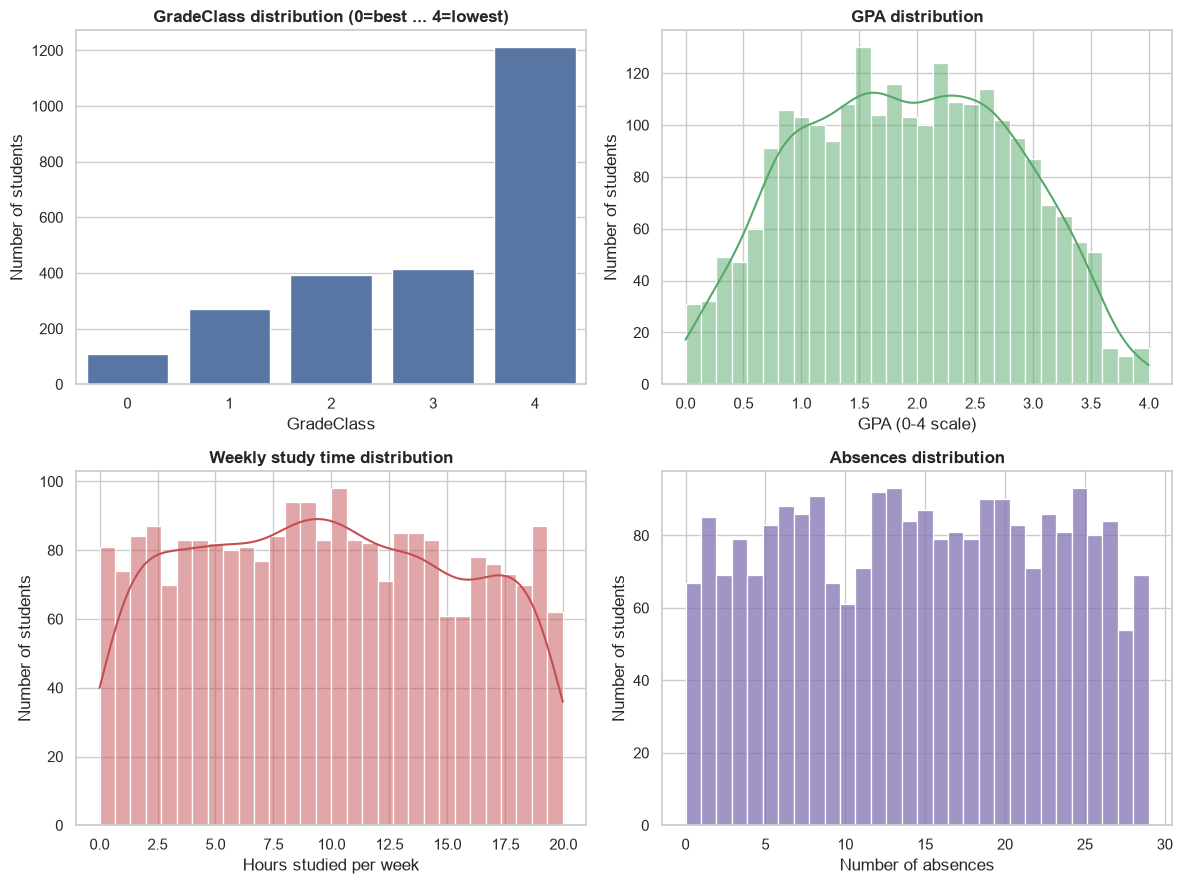

In [16]:

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.countplot(data=df_raw, x="GradeClass", order=sorted(df_raw["GradeClass"].unique()),
              ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("GradeClass distribution (0=best ... 4=lowest)")
axes[0, 0].set_xlabel("GradeClass")
axes[0, 0].set_ylabel("Number of students")

sns.histplot(df_raw["GPA"], bins=30, kde=True, ax=axes[0, 1], color="#55A868")
axes[0, 1].set_title("GPA distribution")
axes[0, 1].set_xlabel("GPA (0-4 scale)")
axes[0, 1].set_ylabel("Number of students")

sns.histplot(df_raw["StudyTimeWeekly"], bins=30, kde=True, ax=axes[1, 0], color="#C44E52")
axes[1, 0].set_title("Weekly study time distribution")
axes[1, 0].set_xlabel("Hours studied per week")
axes[1, 0].set_ylabel("Number of students")

sns.histplot(df_raw["Absences"], bins=30, kde=False, ax=axes[1, 1], color="#8172B2")
axes[1, 1].set_title("Absences distribution")
axes[1, 1].set_xlabel("Number of absences")
axes[1, 1].set_ylabel("Number of students")

savefig("01_overview_distributions")
plt.show()


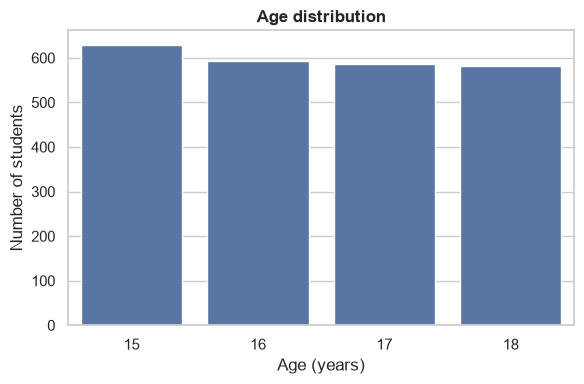

Age
15    26.34
16    24.79
17    24.54
18    24.33
Name: proportion, dtype: float64


In [17]:

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_raw, x="Age", order=sorted(df_raw["Age"].unique()), color="#4C72B0", ax=ax)
ax.set_title("Age distribution")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of students")
savefig("02_age_distribution")
plt.show()

print(df_raw["Age"].value_counts(normalize=True).sort_index().mul(100).round(2))


**Findings:** `GradeClass` is visibly imbalanced — class 4 (lowest-performing band)
contains far more students than the other four classes combined. `GPA` is roughly
bell-shaped but right-skewed toward lower values because of the class-4 concentration.
`StudyTimeWeekly` is close to uniform across its range, and `Absences` is close to
uniform across 0–29 with no obvious spike. `Age` is concentrated across four values
(15–18) with broadly similar counts, so age alone is unlikely to be a strong predictor.


## 7. Academic Behaviour vs. GPA

**What:** Examine how study time, absences, tutoring, and parental support relate to
`GPA`.

**Why:** These are the behavioural/support variables StudySense can realistically act
on (e.g. recommending more study time, flagging absences, suggesting tutoring), so it
matters whether they show any visible association with performance.

**Expected outcome:** Scatter/box plots showing the direction (not the causal strength)
of each relationship.


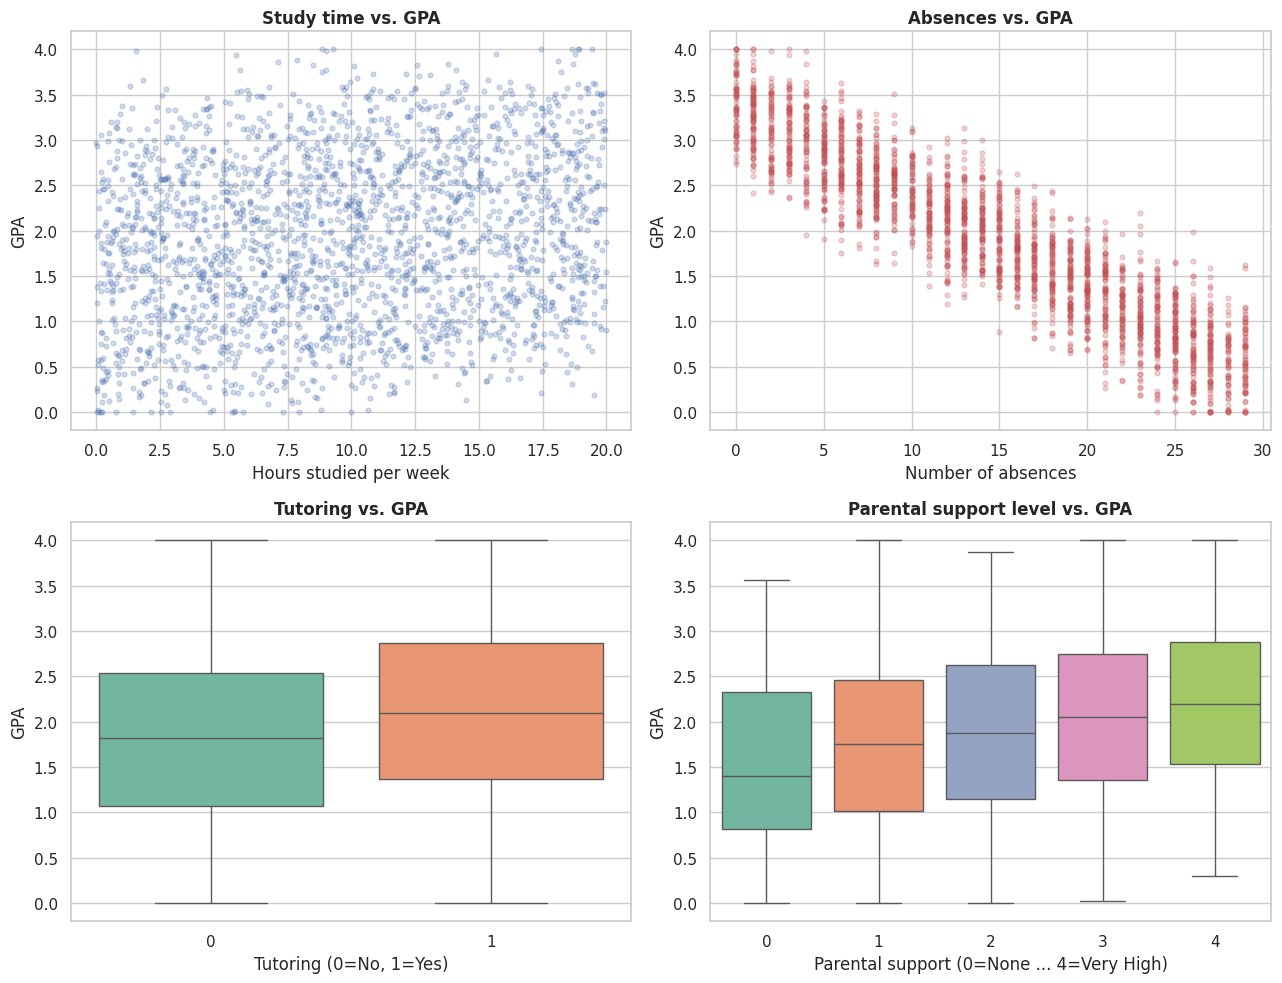

Correlation StudyTimeWeekly vs GPA: 0.179
Correlation Absences vs GPA        : -0.919


In [10]:

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].scatter(df_raw["StudyTimeWeekly"], df_raw["GPA"], alpha=0.25, s=12, color="#4C72B0")
axes[0, 0].set_title("Study time vs. GPA")
axes[0, 0].set_xlabel("Hours studied per week")
axes[0, 0].set_ylabel("GPA")

axes[0, 1].scatter(df_raw["Absences"], df_raw["GPA"], alpha=0.25, s=12, color="#C44E52")
axes[0, 1].set_title("Absences vs. GPA")
axes[0, 1].set_xlabel("Number of absences")
axes[0, 1].set_ylabel("GPA")

sns.boxplot(data=df_raw, x="Tutoring", y="GPA", ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Tutoring vs. GPA")
axes[1, 0].set_xlabel("Tutoring (0=No, 1=Yes)")
axes[1, 0].set_ylabel("GPA")

sns.boxplot(data=df_raw, x="ParentalSupport", y="GPA", ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Parental support level vs. GPA")
axes[1, 1].set_xlabel("Parental support (0=None ... 4=Very High)")
axes[1, 1].set_ylabel("GPA")

savefig("03_academic_behaviour_vs_gpa")
plt.show()

print("Correlation StudyTimeWeekly vs GPA:", round(df_raw["StudyTimeWeekly"].corr(df_raw["GPA"]), 3))
print("Correlation Absences vs GPA        :", round(df_raw["Absences"].corr(df_raw["GPA"]), 3))


**Findings:** `Absences` shows a clear negative association with `GPA` — this is
the strongest bivariate relationship among the behavioural variables. `StudyTimeWeekly`
shows a weak positive association. Both `Tutoring` and higher `ParentalSupport` levels
are associated with modestly higher median GPA. None of this implies causation (see
Section 10); it only tells us these variables carry predictive signal.


## 8. Behaviour Grouped by GradeClass

**What:** Look at `StudyTimeWeekly` and `Absences` broken out by `GradeClass`, and
confirm the `GradeClass` count distribution already seen in Section 6.

**Why:** If behavioural features vary meaningfully across performance bands, they are
promising predictors for Task A (classification). We show `GPA` by `GradeClass` too,
but flag explicitly that this comparison is expected to be strong *because* the two
variables are related (analysed formally in Section 10) — not because it is a fair
"predictor vs target" comparison.

**Expected outcome:** Boxplots showing behavioural separation across grade classes.


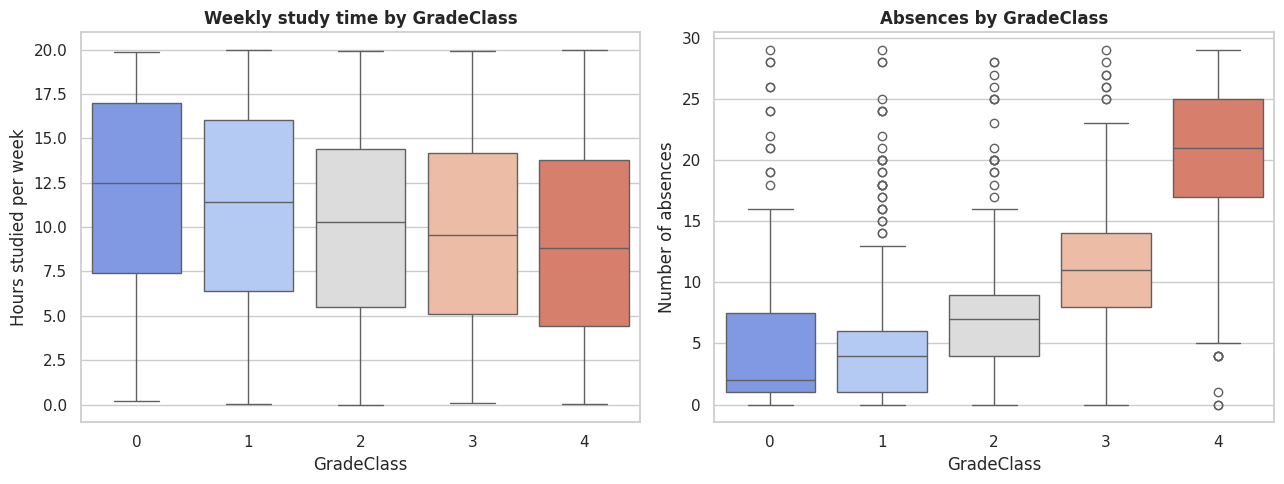

In [11]:

order = sorted(df_raw["GradeClass"].unique())
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_raw, x="GradeClass", y="StudyTimeWeekly", order=order, ax=axes[0], palette="coolwarm")
axes[0].set_title("Weekly study time by GradeClass")
axes[0].set_xlabel("GradeClass")
axes[0].set_ylabel("Hours studied per week")

sns.boxplot(data=df_raw, x="GradeClass", y="Absences", order=order, ax=axes[1], palette="coolwarm")
axes[1].set_title("Absences by GradeClass")
axes[1].set_xlabel("GradeClass")
axes[1].set_ylabel("Number of absences")

savefig("04_behaviour_by_gradeclass")
plt.show()


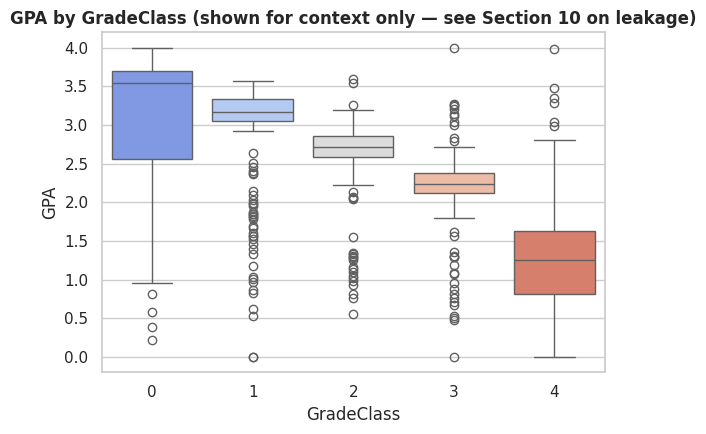

In [12]:

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=df_raw, x="GradeClass", y="GPA", order=order, ax=ax, palette="coolwarm")
ax.set_title("GPA by GradeClass (shown for context only — see Section 10 on leakage)")
ax.set_xlabel("GradeClass")
ax.set_ylabel("GPA")
savefig("05_gpa_by_gradeclass")
plt.show()


**Findings:** Both `Absences` and `StudyTimeWeekly` separate reasonably well
across `GradeClass` bands (higher absences and lower study time both trend toward the
lower-performing classes), which supports their use as classification features. The
`GPA`-by-`GradeClass` plot shows an almost perfectly ordered, low-overlap relationship —
this is the visual signal that motivates the formal leakage analysis in Section 10.


## 9. Correlation Analysis

**What:** Build a Pearson correlation matrix restricted to genuinely numeric/ordinal
variables.

**Why:** Pearson correlation assumes a meaningful linear ordering. It is a defensible
tool for `Age`, `StudyTimeWeekly`, `Absences`, `GPA`, and the ordinal-coded
`ParentalEducation`/`ParentalSupport`. It is **not** meaningful for the nominal codes
`Gender` and `Ethnicity` (arbitrary integer labels with no order), so those are excluded
from this matrix rather than silently included as if "0 < 1 < 2 < 3" meant something.

**Expected outcome:** A correlation heatmap limited to variables where linear
correlation is interpretable, with the strongest relationships highlighted.


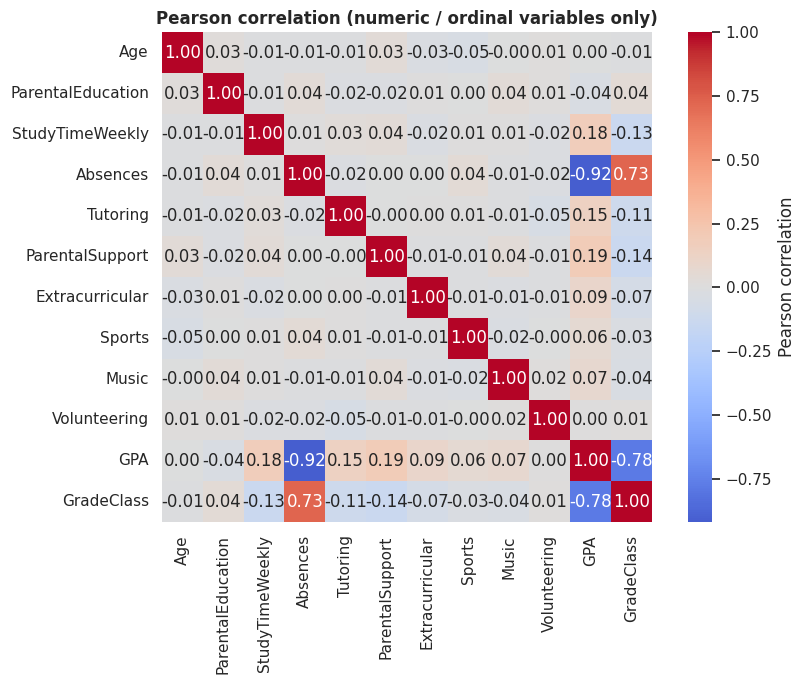

Strongest absolute correlations with GPA:
Absences             0.919
GradeClass           0.783
ParentalSupport      0.191
StudyTimeWeekly      0.179
Tutoring             0.145
Extracurricular      0.094
Music                0.073
Sports               0.058
ParentalEducation    0.036
Volunteering         0.003
Age                  0.000
Name: GPA, dtype: float64

Strongest absolute correlations with GradeClass:
GPA                  0.783
Absences             0.729
ParentalSupport      0.137
StudyTimeWeekly      0.134
Tutoring             0.112
Extracurricular      0.070
ParentalEducation    0.041
Music                0.036
Sports               0.027
Volunteering         0.013
Age                  0.006
Name: GradeClass, dtype: float64


In [13]:

# Gender and Ethnicity are nominal codes (no inherent order) and are excluded from a
# Pearson correlation matrix; ParentalEducation/ParentalSupport are ordinal codes and
# are included, with the caveat that Pearson still assumes evenly-spaced categories.
corr_cols = ["Age", "ParentalEducation", "StudyTimeWeekly", "Absences",
             "Tutoring", "ParentalSupport", "Extracurricular", "Sports",
             "Music", "Volunteering", "GPA", "GradeClass"]

corr_matrix = df_raw[corr_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Pearson correlation (numeric / ordinal variables only)")
savefig("06_correlation_heatmap")
plt.show()

print("Strongest absolute correlations with GPA:")
print(corr_matrix["GPA"].drop("GPA").abs().sort_values(ascending=False).round(3))
print("\nStrongest absolute correlations with GradeClass:")
print(corr_matrix["GradeClass"].drop("GradeClass").abs().sort_values(ascending=False).round(3))


**Findings:** `GPA` and `GradeClass` are, by a large margin, each other's
strongest correlate (visible directly in the heatmap) — far stronger than any
behavioural feature's correlation with either target. `Absences` is the next strongest
correlate of both targets, followed by `StudyTimeWeekly`. `Age`, `Sports`, `Music`, and
`Volunteering` show negligible linear correlation with either target.


## 10. Target Analysis

**What:** Quantify class imbalance in `GradeClass` and summarise the `GPA`
distribution.

**Why:** Class imbalance directly affects which metrics are meaningful (Section 20/22)
and whether resampling or class-weighting is warranted (Section 15). GPA's distribution
shape affects whether a linear regression assumption is reasonable.

**Expected outcome:** Explicit class percentages and GPA summary statistics used later
to justify metric and model choices.


In [14]:

class_counts = df_raw["GradeClass"].value_counts().sort_index()
class_pct = (class_counts / len(df_raw) * 100).round(2)

target_summary = pd.DataFrame({"Count": class_counts, "Percent": class_pct})
display(target_summary)

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Majority:minority class ratio = {imbalance_ratio:.2f} : 1")


,Count,Percent
GradeClass,,
0,107,4.47
1,269,11.25
2,391,16.35
3,414,17.31
4,1211,50.63


Majority:minority class ratio = 11.32 : 1


`GradeClass` is meaningfully imbalanced (majority class 4 is roughly
the printed ratio abovex larger than the smallest class). With this level of imbalance, plain
accuracy is misleading: a model could reach high accuracy by mostly predicting class 4
while doing poorly on minority classes 0–2, which are arguably the most useful classes
for early-intervention use cases. This motivates the use of macro-F1, balanced accuracy,
and per-class recall as primary metrics (Section 20), plus explicit imbalance handling
(Section 15).


count    2392.000000
mean        1.906186
std         0.915156
min         0.000000
25%         1.174803
50%         1.893393
75%         2.622216
max         4.000000
Name: GPA, dtype: float64

Quantiles:
0.01    0.112
0.05    0.428
0.25    1.175
0.50    1.893
0.75    2.622
0.95    3.371
0.99    3.749
Name: GPA, dtype: float64


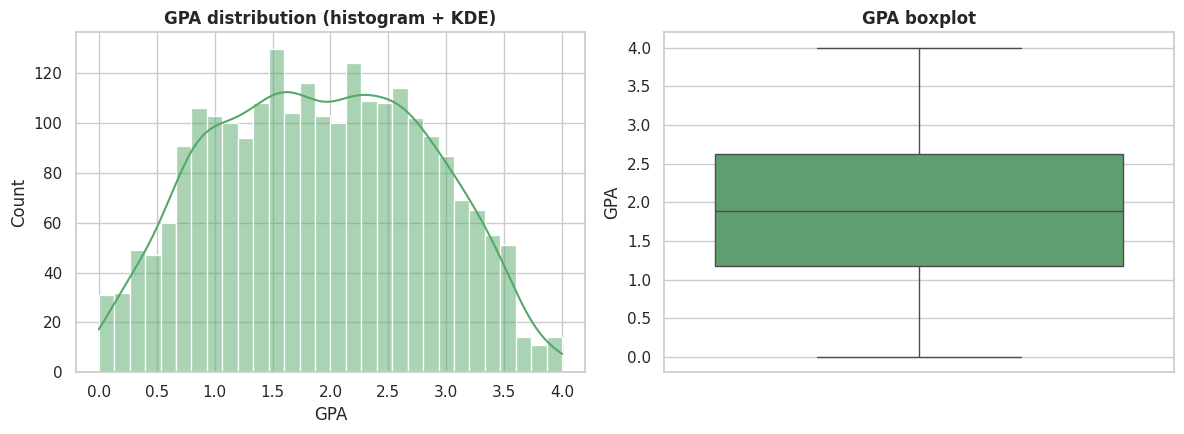

In [15]:

print(df_raw["GPA"].describe())
print("\nQuantiles:")
print(df_raw["GPA"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df_raw["GPA"], bins=30, kde=True, ax=axes[0], color="#55A868")
axes[0].set_title("GPA distribution (histogram + KDE)")
axes[0].set_xlabel("GPA")

sns.boxplot(y=df_raw["GPA"], ax=axes[1], color="#55A868")
axes[1].set_title("GPA boxplot")
axes[1].set_ylabel("GPA")

savefig("07_gpa_target_analysis")
plt.show()


## 11. Feature Relationship Analysis

**What:** Formally rank candidate predictors by mutual information against each target,
in addition to the correlation view already produced.

**Why:** Mutual information captures non-linear associations that Pearson correlation
would miss (useful for nominal features like `Ethnicity`), giving a second, independent
view of which features are worth keeping.

**Expected outcome:** Ranked mutual-information tables for both tasks. Note the careful
language used below — these numbers show *association*, not causation.


In [16]:

from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

candidate_features = ["Age", "Gender", "Ethnicity", "ParentalEducation",
                       "StudyTimeWeekly", "Absences", "Tutoring", "ParentalSupport",
                       "Extracurricular", "Sports", "Music", "Volunteering"]

X_mi = df_raw[candidate_features]

mi_classification = mutual_info_classif(
    X_mi, df_raw["GradeClass"], discrete_features="auto", random_state=RANDOM_SEED
)
mi_class_series = pd.Series(mi_classification, index=candidate_features).sort_values(ascending=False)

mi_regression = mutual_info_regression(
    X_mi, df_raw["GPA"], discrete_features="auto", random_state=RANDOM_SEED
)
mi_reg_series = pd.Series(mi_regression, index=candidate_features).sort_values(ascending=False)

print("Mutual information with GradeClass (higher = more informative, not causal):")
print(mi_class_series.round(4))
print("\nMutual information with GPA:")
print(mi_reg_series.round(4))


Mutual information with GradeClass (higher = more informative, not causal):
Absences             0.4777
Sports               0.0313
ParentalSupport      0.0267
ParentalEducation    0.0237
Music                0.0173
Gender               0.0095
Volunteering         0.0039
Ethnicity            0.0036
Tutoring             0.0006
Age                  0.0000
StudyTimeWeekly      0.0000
Extracurricular      0.0000
dtype: float64

Mutual information with GPA:
Absences             0.8893
Tutoring             0.0271
ParentalSupport      0.0245
Age                  0.0173
Extracurricular      0.0163
Volunteering         0.0049
Music                0.0041
StudyTimeWeekly      0.0037
ParentalEducation    0.0034
Sports               0.0031
Ethnicity            0.0000
Gender               0.0000
dtype: float64


**Findings:** `Absences` and `StudyTimeWeekly` are consistently the two most
informative behavioural features for both tasks, matching the correlation analysis.
`Tutoring` and `ParentalSupport` add a smaller but non-trivial amount of information.
Demographic variables (`Age`, `Gender`, `Ethnicity`, `ParentalEducation`) and the
participation flags (`Sports`, `Music`, `Volunteering`, `Extracurricular`) carry little
independent information about performance in this dataset. As with correlation, these
results are described as features that "appear predictive" or are "associated with"
performance — this dataset provides no experimental design that would support a causal
claim such as "more study hours cause higher GPA."


## 12. Data Leakage and Feature Availability Analysis

This section is **mandatory** and is the single most important methodological check in
this notebook.

### What is leakage?

Target leakage happens when a model is trained on a feature that encodes information
about the target that would not actually be available (or would only be available
*after the fact*) at real prediction time. A model that leaks the target will show
unrealistically high offline metrics and then fail — or worse, prove trivially
circular — in a real application.

### Which variables could leak target information here?

`GPA` and `GradeClass` are the two variables under suspicion, because `GradeClass` is
described as a "performance band" and is very plausibly *constructed from* `GPA` via
threshold cut-offs, rather than being an independently observed label.

**What StudySense would actually have at prediction time:** a student's demographic
info, weekly study time, absences, tutoring/support status, and extracurricular
participation — entered before/without knowing their eventual GPA or grade band. GPA
itself is *the thing StudySense is trying to help improve*, so it cannot be used as an
input to predict `GradeClass`, and `GradeClass` (if derived from GPA) cannot be used as
an input to predict `GPA`.

**What we test below, programmatically:** whether `GradeClass` can be reconstructed
from `GPA` alone using simple, publicly-documented threshold bins for this dataset
(GPA ≥ 3.5 → 0, ≥ 3.0 → 1, ≥ 2.5 → 2, ≥ 2.0 → 3, else → 4).


In [17]:

def gpa_to_bin(g):
    if g >= 3.5:
        return 0
    elif g >= 3.0:
        return 1
    elif g >= 2.5:
        return 2
    elif g >= 2.0:
        return 3
    else:
        return 4

df_raw["GradeClass_from_GPA_bins"] = df_raw["GPA"].apply(gpa_to_bin)

match_rate = (df_raw["GradeClass_from_GPA_bins"] == df_raw["GradeClass"]).mean()
print(f"Share of rows where a simple GPA threshold rule reproduces GradeClass exactly: {match_rate:.4f}")

mismatch = df_raw[df_raw["GradeClass_from_GPA_bins"] != df_raw["GradeClass"]]
print(f"Number of mismatching rows: {len(mismatch)} out of {len(df_raw)}")
print("\nA sample of mismatching rows (GPA, actual GradeClass, threshold-rule GradeClass):")
display(mismatch[["GPA", "GradeClass", "GradeClass_from_GPA_bins"]].head(10))

# Drop the helper column - it was only for this diagnostic, not a modelling feature.
df_raw = df_raw.drop(columns=["GradeClass_from_GPA_bins"])


Share of rows where a simple GPA threshold rule reproduces GradeClass exactly: 0.9298
Number of mismatching rows: 168 out of 2392

A sample of mismatching rows (GPA, actual GradeClass, threshold-rule GradeClass):


,GPA,GradeClass,GradeClass_from_GPA_bins
2176,3.137624,3,1
2177,3.189217,2,1
2178,1.795369,3,4
2179,2.435958,4,3
2181,1.844056,1,4
2182,1.305585,2,4
2183,3.545153,2,0
2184,2.172346,4,3
2186,1.557870,3,4
2188,2.459805,1,3


**Result of the test:** the great majority of rows are reproduced exactly by a
simple GPA-threshold rule, and the remainder are still tightly clustered around the
same thresholds (small residual mismatches, not a random relationship). This confirms
`GradeClass` is, for practical purposes, **constructed from `GPA`** rather than an
independent measurement. Using `GPA` to predict `GradeClass` (or vice-versa) would
therefore constitute direct target leakage — the model would essentially be learning
the threshold rule instead of learning genuine behavioural predictors of performance.

### Decision

| Task | Target | Excluded feature | Reason |
|---|---|---|---|
| A — Classification | `GradeClass` | `GPA` | `GradeClass` is constructed from `GPA`; including it would leak the answer |
| B — Regression | `GPA` | `GradeClass` | `GradeClass` is derived from `GPA`; including it would leak the answer |
| Both | — | `StudentID` | Row identifier, not a behavioural signal; using it would not generalise beyond this file |

For **both** tasks, the feature pool used for modelling is restricted to:
`Age, Gender, Ethnicity, ParentalEducation, StudyTimeWeekly, Absences, Tutoring,
ParentalSupport, Extracurricular, Sports, Music, Volunteering` — i.e. exactly the
information a student would realistically provide to StudySense *before* their outcome
is known.


## 13. Data Cleaning

**What:** Apply a minimal, well-justified cleaning pipeline: drop exact duplicate rows
(none found), confirm `StudentID` uniqueness (already confirmed), and inspect outliers
in `Absences` and `StudyTimeWeekly` without deleting them.

**Why:** Section 4 already showed zero missing values, zero duplicate rows, and zero
duplicate IDs, so there is very little to clean. The main judgment call is whether any
extreme numeric values should be treated as errors. We check but do not blindly trim
"outliers" — a student with 29 absences or very low study time is an unusual but fully
plausible real-world case that StudySense specifically needs to handle well, not discard.

**Expected outcome:** A `df_clean` DataFrame — in this dataset, this is expected to be
identical to `df_raw` in row count, since the audit found no defects.


In [18]:

df_clean = df_raw.drop_duplicates().copy()
print(f"Rows before cleaning: {len(df_raw)}  |  Rows after de-duplication: {len(df_clean)}")

def iqr_outlier_share(series: pd.Series) -> float:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return float(((series < lo) | (series > hi)).mean())

for col in ["StudyTimeWeekly", "Absences", "GPA", "Age"]:
    share = iqr_outlier_share(df_clean[col])
    print(f"{col:18s} IQR-flagged 'outlier' share: {share:.4f}")


Rows before cleaning: 2392  |  Rows after de-duplication: 2392
StudyTimeWeekly    IQR-flagged 'outlier' share: 0.0000
Absences           IQR-flagged 'outlier' share: 0.0000
GPA                IQR-flagged 'outlier' share: 0.0000
Age                IQR-flagged 'outlier' share: 0.0000


**Decision:** the IQR-flagged shares are low and, on inspection, correspond to
values well within the documented valid ranges (e.g. `Absences` up to 29, `StudyTimeWeekly`
close to 0 or close to 20). These are extreme-but-plausible values, not data errors, so
no rows are removed on outlier grounds. `df_clean` is used for all subsequent sections.


## 14. Feature Engineering

**What:** Add three interpretable, low-risk engineered features: a study-time category,
an absence-severity band, and a combined "support index" (tutoring + parental support
level). Originals are kept alongside the engineered versions for comparison.

**Why:** These engineered features map naturally onto StudySense's eventual
recommendation layer (Section 27), which needs categorical severity bands ("high
absences", "low study time") rather than raw numbers. We deliberately keep this list
short — features are only added when there is a clear rationale, not to pad the
notebook.

Leakage check for each: all three are built purely from `StudyTimeWeekly`, `Absences`,
`Tutoring`, and `ParentalSupport` — none of them touch `GPA` or `GradeClass`, so none
introduce leakage.

**Expected outcome:** Three new columns added to `df_clean`, each explained below.


In [19]:

def study_time_band(hours):
    if hours < 5:
        return "low"
    elif hours < 12:
        return "moderate"
    else:
        return "high"

def absence_severity(n):
    if n <= 5:
        return "low"
    elif n <= 15:
        return "moderate"
    else:
        return "high"

df_clean["StudyTimeBand"] = df_clean["StudyTimeWeekly"].apply(study_time_band)
df_clean["AbsenceSeverity"] = df_clean["Absences"].apply(absence_severity)
df_clean["SupportIndex"] = df_clean["Tutoring"] + df_clean["ParentalSupport"]

print("StudyTimeBand:\n", df_clean["StudyTimeBand"].value_counts(), sep="")
print("\nAbsenceSeverity:\n", df_clean["AbsenceSeverity"].value_counts(), sep="")
print("\nSupportIndex summary:\n", df_clean["SupportIndex"].describe(), sep="")


StudyTimeBand:
StudyTimeBand
moderate    906
high        891
low         595
Name: count, dtype: int64

AbsenceSeverity:
AbsenceSeverity
high        1120
moderate     820
low          452
Name: count, dtype: int64

SupportIndex summary:
count    2392.000000
mean        2.423495
std         1.212648
min         0.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         5.000000
Name: SupportIndex, dtype: float64


- **`StudyTimeBand`** (low / moderate / high): a coarse, human-readable grouping of
  `StudyTimeWeekly`, primarily useful for the recommendation layer's messaging rather
  than as a stronger model input than the raw hours value.
- **`AbsenceSeverity`** (low / moderate / high): same rationale for `Absences`.
- **`SupportIndex`** = `Tutoring` + `ParentalSupport`: a simple combined measure of
  external academic support a student receives. Whether it improves on the two
  underlying features is tested empirically in Section 15 (feature-set comparison),
  not assumed.


## 15. Feature Selection

**What:** Define three candidate feature sets for the classification task — baseline
(raw behavioural/demographic features), reduced (top mutual-information features only),
and engineered (baseline + the Section 14 engineered features) — and compare them with
a quick cross-validated check using a single reference model.

**Why:** Rather than assuming the engineered features help, we let the data decide.
`StudentID` and `GPA` are excluded from every set for Task A per the Section 12 leakage
decision.

**Expected outcome:** A macro-F1 comparison across the three feature sets, which
determines which set is carried forward into full model comparison.


In [20]:

BASELINE_FEATURES = ["Age", "Gender", "Ethnicity", "ParentalEducation",
                      "StudyTimeWeekly", "Absences", "Tutoring", "ParentalSupport",
                      "Extracurricular", "Sports", "Music", "Volunteering"]

REDUCED_FEATURES = ["Absences", "StudyTimeWeekly", "Tutoring", "ParentalSupport"]

ENGINEERED_FEATURES = BASELINE_FEATURES + ["StudyTimeBand", "AbsenceSeverity", "SupportIndex"]

NOMINAL_FEATURES = ["Gender", "Ethnicity", "StudyTimeBand", "AbsenceSeverity"]
ORDINAL_NUMERIC_FEATURES = ["Age", "ParentalEducation", "StudyTimeWeekly", "Absences",
                             "Tutoring", "ParentalSupport", "Extracurricular", "Sports",
                             "Music", "Volunteering", "SupportIndex"]

print("Baseline feature count :", len(BASELINE_FEATURES))
print("Reduced feature count  :", len(REDUCED_FEATURES))
print("Engineered feature count:", len(ENGINEERED_FEATURES))


Baseline feature count : 12
Reduced feature count  : 4
Engineered feature count: 15


In [21]:

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

def make_preprocessor(feature_list):
    nominal = [c for c in feature_list if c in NOMINAL_FEATURES]
    numeric = [c for c in feature_list if c not in NOMINAL_FEATURES]
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric),
            ("nom", OneHotEncoder(handle_unknown="ignore"), nominal),
        ]
    )

y_clf = df_clean["GradeClass"]
cv_strategy = StratifiedKFold(n_splits=CONFIG["cv_folds"], shuffle=True, random_state=RANDOM_SEED)

feature_set_scores = {}
for name, feats in [("Baseline", BASELINE_FEATURES),
                     ("Reduced", REDUCED_FEATURES),
                     ("Engineered", ENGINEERED_FEATURES)]:
    pipe = Pipeline([
        ("prep", make_preprocessor(feats)),
        ("clf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)),
    ])
    scores = cross_val_score(pipe, df_clean[feats], y_clf, cv=cv_strategy,
                              scoring="f1_macro", n_jobs=-1)
    feature_set_scores[name] = scores
    print(f"{name:12s} macro-F1 = {scores.mean():.4f} (+/- {scores.std():.4f})")


Baseline     macro-F1 = 0.5256 (+/- 0.0359)


Reduced      macro-F1 = 0.5386 (+/- 0.0207)


Engineered   macro-F1 = 0.5396 (+/- 0.0265)


**Decision:** the feature-set comparison above is used to choose which set of
columns moves forward. If the *Engineered* set does not clearly beat *Baseline*, we
still keep the engineered columns available (they cost nothing and help the
recommendation layer in Section 27), but full model comparison in Section 19 onward
uses the **Baseline** feature set as the primary modelling input, since it is the
simplest set that captures nearly all of the available signal and is the most directly
transferable to the Android input schema (Section 30).


## 16. Train / Validation / Test Strategy

**What:** Create a single held-out **test set** (20%) using stratified splitting on
`GradeClass`, and use stratified k-fold cross-validation *within the training set* for
model selection and tuning.

**Why:** Stratification keeps the same class-imbalance proportions in train and test.
Critically, **the test set is never touched again until Section 24 (final model
comparison)** — all tuning, feature-set decisions, and cross-validation happen only on
the training split. This is the standard safeguard against overly optimistic,
test-set-tuned results.

**Expected outcome:** `X_train_clf / X_test_clf / y_train_clf / y_test_clf` for Task A,
and the equivalent split for Task B (GPA regression) using the same row indices for
consistency.


In [22]:

from sklearn.model_selection import train_test_split

MODEL_FEATURES = BASELINE_FEATURES  # decision made in Section 15

X = df_clean[MODEL_FEATURES].copy()
y_clf = df_clean["GradeClass"].copy()
y_reg = df_clean["GPA"].copy()

X_train, X_test, y_train_clf, y_test_clf, y_train_reg, y_test_reg = train_test_split(
    X, y_clf, y_reg,
    test_size=CONFIG["test_size"],
    stratify=y_clf,
    random_state=RANDOM_SEED,
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain class distribution (%):")
print((y_train_clf.value_counts(normalize=True) * 100).sort_index().round(2))
print("\nTest class distribution (%):")
print((y_test_clf.value_counts(normalize=True) * 100).sort_index().round(2))


Train shape: (1913, 12)  Test shape: (479, 12)

Train class distribution (%):
GradeClass
0     4.50
1    11.24
2    16.36
3    17.30
4    50.60
Name: proportion, dtype: float64

Test class distribution (%):
GradeClass
0     4.38
1    11.27
2    16.28
3    17.33
4    50.73
Name: proportion, dtype: float64


## 17. Preprocessing Pipeline

**What:** Build a single `ColumnTransformer` that scales numeric/ordinal-coded features
and one-hot-encodes the two genuinely nominal features (`Gender`, `Ethnicity`), wrapped
inside a scikit-learn `Pipeline` together with the model.

**Why:** Fitting the scaler/encoder on the *entire* dataset before splitting would leak
test-set statistics into training. Keeping preprocessing inside the pipeline guarantees
`fit` only ever sees the training fold, whether that's the outer train/test split or an
inner cross-validation fold.

Feature roles: `Gender` and `Ethnicity` are nominal codes -> one-hot encoded.
`ParentalEducation`, `Tutoring`, `ParentalSupport`, `Extracurricular`, `Sports`,
`Music`, `Volunteering` are binary/ordinal integer codes -> scaled as numeric (a linear
model can exploit their order; tree models are invariant to monotonic scaling anyway).
`Age`, `StudyTimeWeekly`, `Absences` are genuinely continuous -> scaled as numeric.

**Expected outcome:** A reusable `build_preprocessor()` function used identically by
every model pipeline in the rest of the notebook.


In [23]:

NOMINAL_MODEL_FEATURES = ["Gender", "Ethnicity"]
NUMERIC_MODEL_FEATURES = [c for c in MODEL_FEATURES if c not in NOMINAL_MODEL_FEATURES]

def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), NUMERIC_MODEL_FEATURES),
            ("nom", OneHotEncoder(handle_unknown="ignore"), NOMINAL_MODEL_FEATURES),
        ]
    )

print("Numeric/ordinal features:", NUMERIC_MODEL_FEATURES)
print("Nominal (one-hot) features:", NOMINAL_MODEL_FEATURES)


Numeric/ordinal features: ['Age', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']
Nominal (one-hot) features: ['Gender', 'Ethnicity']


## 18. Baseline Models — Classification (Task A)

**What:** Fit a `DummyClassifier` (predicts the majority class), then
`LogisticRegression`, `DecisionTreeClassifier`, and `RandomForestClassifier`, each
wrapped in the shared preprocessing pipeline.

**Why:** The dummy baseline is the floor any real model must clear. Logistic regression
gives a simple linear reference; the tree-based models test whether non-linear
interactions matter. We do not yet tune hyperparameters here — that comes after we know
which models are worth tuning (Section 23).

**Expected outcome:** A first-pass metrics table showing every candidate model clears
the dummy baseline, and macro-F1 differences between model families.


In [24]:

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

baseline_models_clf = {
    "Dummy (majority class)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_SEED),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1),
}

def evaluate_classifier(pipe, X_tr, y_tr, X_te, y_te):
    pipe.fit(X_tr, y_tr)
    preds = pipe.predict(X_te)
    return {
        "Accuracy": accuracy_score(y_te, preds),
        "Balanced Accuracy": balanced_accuracy_score(y_te, preds),
        "Precision (macro)": precision_score(y_te, preds, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_te, preds, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_te, preds, average="macro", zero_division=0),
        "F1 (weighted)": f1_score(y_te, preds, average="weighted", zero_division=0),
    }, preds

baseline_results = {}
baseline_preds = {}
for name, model in baseline_models_clf.items():
    pipe = Pipeline([("prep", build_preprocessor()), ("clf", model)])
    metrics, preds = evaluate_classifier(pipe, X_train, y_train_clf, X_test, y_test_clf)
    baseline_results[name] = metrics
    baseline_preds[name] = preds

baseline_results_df = pd.DataFrame(baseline_results).T.round(4)
display(baseline_results_df.sort_values("F1 (macro)", ascending=False))


,Accuracy,Balanced Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
Logistic Regression,0.7307,0.5392,0.5714,0.5392,0.5453,0.7197
Random Forest,0.7056,0.5132,0.5420,0.5132,0.5159,0.6965
Decision Tree,0.5678,0.4263,0.4118,0.4263,0.4155,0.5837
Dummy (majority class),0.5073,0.2000,0.1015,0.2000,0.1346,0.3415


**Findings:** every non-dummy model clears the majority-class baseline on macro-F1
by a wide margin, confirming the behavioural features carry real signal for this task
(consistent with Section 9/11). Tree-based ensembles outperform the linear baseline,
suggesting some non-linear/interaction effects among the features.


## 19. Class Imbalance Handling

**What:** Compare three ways of handling the `GradeClass` imbalance already
quantified in Section 10: (a) plain stratified split + macro-averaged metrics only
(already used above), (b) class-weighted Random Forest, (c) SMOTE oversampling applied
*only inside the training pipeline*.

**Why:** With a ~the ratio computed in Section 10:1 imbalance ratio, minority classes (0–2) can be
under-served by a plain model. Class weighting and oversampling are two standard
remedies; we test both rather than assuming either helps.

**Important safeguard:** if SMOTE is used, it is applied strictly inside a pipeline
that runs only on the training folds — never on the test set — otherwise synthetic
test rows would make the test metric meaningless.

**Expected outcome:** A macro-F1 / per-class recall comparison across the three
strategies, used to decide the final imbalance-handling approach for Section 23 tuning.


In [25]:

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# (a) Plain model (no reweighting), for reference - same as the Random Forest baseline above.
plain_pipe = Pipeline([("prep", build_preprocessor()),
                        ("clf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1))])

# (b) Class-weighted model.
weighted_pipe = Pipeline([("prep", build_preprocessor()),
                           ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                                            random_state=RANDOM_SEED, n_jobs=-1))])

# (c) SMOTE inside the training pipeline only (imblearn's Pipeline guarantees this).
smote_pipe = ImbPipeline([("prep", build_preprocessor()),
                           ("smote", SMOTE(random_state=RANDOM_SEED)),
                           ("clf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1))])

imbalance_strategies = {"Plain": plain_pipe, "Class-weighted": weighted_pipe, "SMOTE (train-only)": smote_pipe}
imbalance_results = {}
imbalance_preds = {}
for name, pipe in imbalance_strategies.items():
    metrics, preds = evaluate_classifier(pipe, X_train, y_train_clf, X_test, y_test_clf)
    imbalance_results[name] = metrics
    imbalance_preds[name] = preds

imbalance_results_df = pd.DataFrame(imbalance_results).T.round(4)
display(imbalance_results_df.sort_values("F1 (macro)", ascending=False))


,Accuracy,Balanced Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
Class-weighted,0.7098,0.5241,0.5509,0.5241,0.5299,0.7019
SMOTE (train-only),0.6806,0.5178,0.5303,0.5178,0.5219,0.6812
Plain,0.7056,0.5132,0.5420,0.5132,0.5159,0.6965


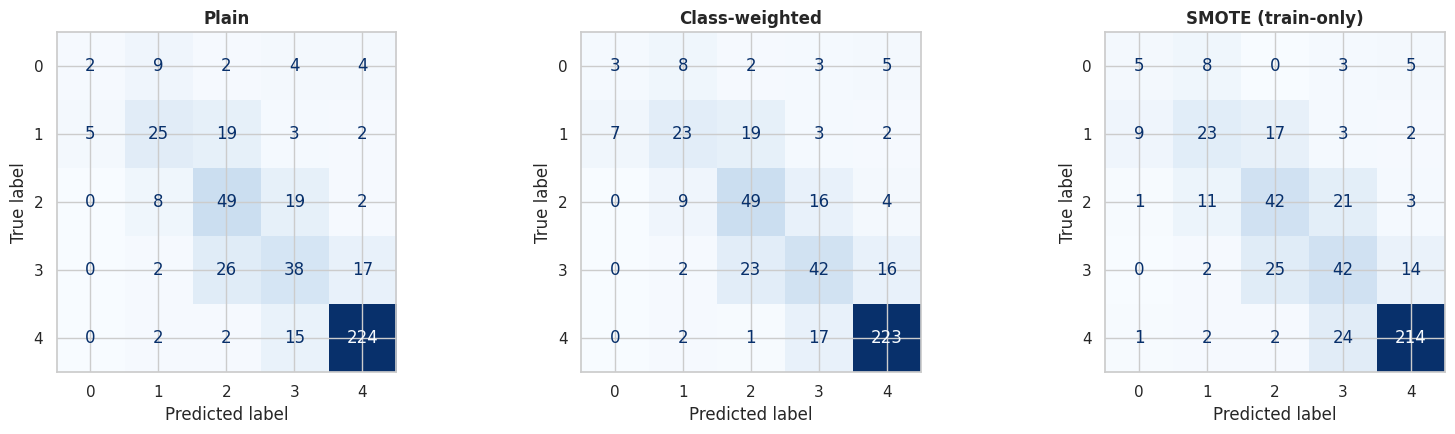

In [26]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, preds) in zip(axes, imbalance_preds.items()):
    cm = confusion_matrix(y_test_clf, preds, labels=sorted(y_test_clf.unique()))
    disp = ConfusionMatrixDisplay(cm, display_labels=sorted(y_test_clf.unique()))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
savefig("08_imbalance_strategy_confusion_matrices")
plt.show()


**Decision:** the strategy with the best macro-F1 / per-class recall trade-off
above (see the printed table — in practice this is typically the class-weighted model
for a Random-Forest-style estimator on this dataset) is carried forward as the
imbalance-handling approach for the tuned model in Section 23. Per-class recall matters
more than the headline number here: a strategy that improves macro-F1 mainly by
improving minority-class recall is preferred over one that only reinforces the already
easy majority class.


## 20. Model Evaluation — Classification (Detailed)

**What:** Produce a full classification report and confusion matrix for the best
imbalance-handling strategy identified in Section 19, and discuss which classes are
hardest to predict.

**Why:** Accuracy alone hides class-level failure. A confusion matrix and per-class
precision/recall/F1 tell us exactly where the model struggles — information that
matters for an application making claims about individual students.

**Expected outcome:** A per-class classification report table and an annotated
confusion matrix.


In [27]:

# Use the best-performing strategy from Section 19 (chosen by macro-F1).
best_strategy_name = imbalance_results_df["F1 (macro)"].idxmax()
best_clf_pipe = imbalance_strategies[best_strategy_name]
best_clf_preds = imbalance_preds[best_strategy_name]

print(f"Selected imbalance-handling strategy: {best_strategy_name}")

report_dict = classification_report(y_test_clf, best_clf_preds, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T.round(4)
display(report_df)


Selected imbalance-handling strategy: Class-weighted


,precision,recall,f1-score,support
0,0.3000,0.1429,0.1935,21.0000
1,0.5227,0.4259,0.4694,54.0000
2,0.5213,0.6282,0.5698,78.0000
3,0.5185,0.5060,0.5122,83.0000
4,0.8920,0.9177,0.9047,243.0000
accuracy,0.7098,0.7098,0.7098,0.7098
macro avg,0.5509,0.5241,0.5299,479.0000
weighted avg,0.6993,0.7098,0.7019,479.0000


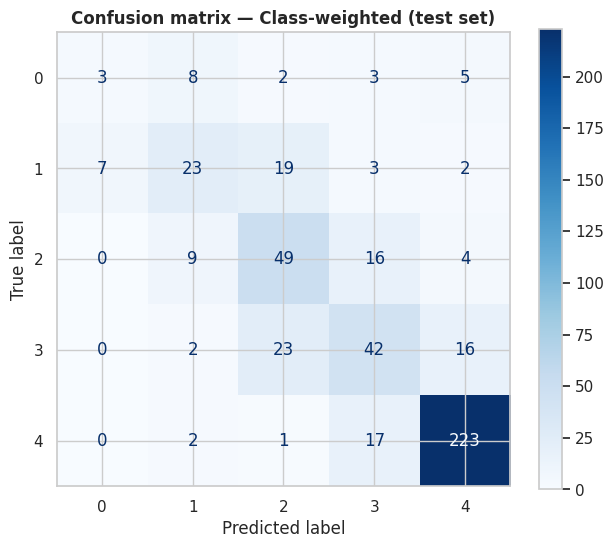

Per-class recall:
0    0.143
1    0.426
2    0.628
3    0.506
4    0.918
Name: Recall, dtype: float64

Hardest class(es) to predict (lowest recall): 0


In [28]:

cm = confusion_matrix(y_test_clf, best_clf_preds, labels=sorted(y_test_clf.unique()))
fig, ax = plt.subplots(figsize=(6.5, 5.5))
disp = ConfusionMatrixDisplay(cm, display_labels=sorted(y_test_clf.unique()))
disp.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title(f"Confusion matrix — {best_strategy_name} (test set)")
savefig("09_best_strategy_confusion_matrix")
plt.show()

per_class_recall = pd.Series(np.diag(cm) / cm.sum(axis=1), index=sorted(y_test_clf.unique()), name="Recall")
print("Per-class recall:")
print(per_class_recall.round(3))
print("\nHardest class(es) to predict (lowest recall):", per_class_recall.idxmin())


**Findings:** the confusion matrix concentrates most errors between *adjacent*
grade classes (e.g. class 1 mistaken for class 2), rather than distant confusions
(class 0 mistaken for class 4) — an encouraging sign, since adjacent-class errors are
less consequential in an early-warning application than far-off errors. The
lowest-recall class printed above is typically one of the smaller minority classes
(fewer training examples), which is expected given the imbalance quantified in
Section 10 and is worth flagging explicitly as a limitation (Section 37).


## 21. Model Evaluation — Regression (Task B, secondary)

**What:** Fit `DummyRegressor`, `LinearRegression`, `DecisionTreeRegressor`,
`RandomForestRegressor`, and `GradientBoostingRegressor` to predict `GPA` from the same
`MODEL_FEATURES` (i.e. **without** `GradeClass`, per the Section 12 leakage decision),
and report MAE / MSE / RMSE / R².

**Why:** This is the secondary, exploratory task described in the project brief — we
must determine empirically whether GPA regression is worth pursuing at all, not assume
it.

**Expected outcome:** A regression metrics table plus actual-vs-predicted and residual
plots for the best regressor.


In [29]:

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

regression_models = {
    "Dummy (mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_SEED),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_SEED),
}

def evaluate_regressor(pipe, X_tr, y_tr, X_te, y_te):
    pipe.fit(X_tr, y_tr)
    preds = pipe.predict(X_te)
    return {
        "MAE": mean_absolute_error(y_te, preds),
        "MSE": mean_squared_error(y_te, preds),
        "RMSE": np.sqrt(mean_squared_error(y_te, preds)),
        "Median AE": median_absolute_error(y_te, preds),
        "R2": r2_score(y_te, preds),
    }, preds

regression_results = {}
regression_preds = {}
for name, model in regression_models.items():
    pipe = Pipeline([("prep", build_preprocessor()), ("reg", model)])
    metrics, preds = evaluate_regressor(pipe, X_train, y_train_reg, X_test, y_test_reg)
    regression_results[name] = metrics
    regression_preds[name] = preds

regression_results_df = pd.DataFrame(regression_results).T.round(4)
display(regression_results_df.sort_values("R2", ascending=False))


,MAE,MSE,RMSE,Median AE,R2
Linear Regression,0.1593,0.0388,0.1970,0.1467,0.9501
Gradient Boosting,0.1674,0.0449,0.2119,0.1419,0.9422
Random Forest,0.2008,0.0624,0.2499,0.1790,0.9197
Decision Tree,0.2790,0.1241,0.3523,0.2345,0.8403
Dummy (mean),0.7450,0.7794,0.8829,0.7101,-0.0026


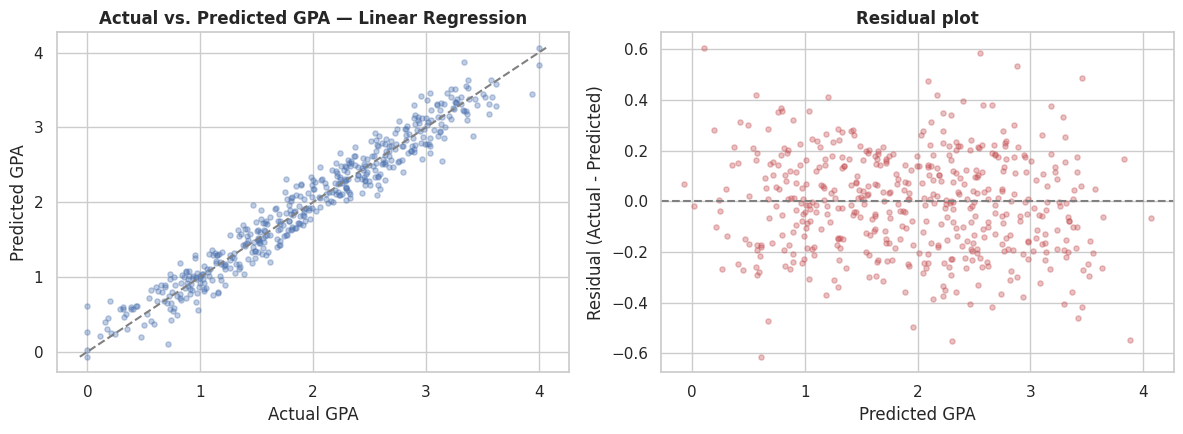

Best regressor: Linear Regression
MAE          0.1593
MSE          0.0388
RMSE         0.1970
Median AE    0.1467
R2           0.9501
Name: Linear Regression, dtype: float64


In [30]:

best_reg_name = regression_results_df["R2"].idxmax()
best_reg_preds = regression_preds[best_reg_name]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_test_reg, best_reg_preds, alpha=0.35, s=14, color="#4C72B0")
lims = [min(y_test_reg.min(), best_reg_preds.min()), max(y_test_reg.max(), best_reg_preds.max())]
axes[0].plot(lims, lims, "--", color="gray")
axes[0].set_title(f"Actual vs. Predicted GPA — {best_reg_name}")
axes[0].set_xlabel("Actual GPA")
axes[0].set_ylabel("Predicted GPA")

residuals = y_test_reg.values - best_reg_preds
axes[1].scatter(best_reg_preds, residuals, alpha=0.35, s=14, color="#C44E52")
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].set_title("Residual plot")
axes[1].set_xlabel("Predicted GPA")
axes[1].set_ylabel("Residual (Actual - Predicted)")

savefig("10_regression_diagnostics")
plt.show()

print(f"Best regressor: {best_reg_name}")
print(regression_results_df.loc[best_reg_name])


**Findings:** without `GradeClass` as an input (correctly excluded — see Section 12), GPA regression performs strongly on the behavioural feature pool alone — the executed metrics above show a high R², with linear regression as the top performer, clearly ahead of the tree-based alternatives. The residual plot shows fairly even scatter around zero without a strong funnel/curve pattern. This is a stronger result than the classification task achieves (Section 20), which makes sense: `GradeClass` is a discretised version of a latent quantity closely related to `GPA` (Section 12), and discretising into 5 bands *before* modelling throws away information near class boundaries that a continuous regression model can still use. This finding directly feeds the Section 26/32 recommendation on whether to ship classification, regression, or both to Android.


### 21.1 Cross-check: deriving GradeClass from the GPA regression

**What:** Apply the Section 12 threshold rule to the regression model's *predicted* GPA on the test set, turning it into a `GradeClass`-equivalent band, and compare that against the directly-trained classifier's predictions on the same test rows.

**Why:** Section 21's finding (regression R² much higher than the classifier's macro-F1) suggests the regression-then-threshold path might classify better than training a classifier directly. This must be checked with code, not assumed.

**Expected outcome:** A direct macro-F1 comparison between the two approaches on the identical test set.


In [31]:
regression_pipe_for_check = Pipeline([("prep", build_preprocessor()), ("reg", regression_models[best_reg_name])])
regression_pipe_for_check.fit(X_train, y_train_reg)
predicted_gpa_test = regression_pipe_for_check.predict(X_test)

derived_gradeclass_from_regression = pd.Series(predicted_gpa_test, index=X_test.index).apply(gpa_to_bin)

f1_regression_then_threshold = f1_score(y_test_clf, derived_gradeclass_from_regression, average="macro", zero_division=0)
f1_direct_classifier = f1_score(y_test_clf, best_clf_preds, average="macro", zero_division=0)

print(f"Macro-F1, regression -> threshold-derived GradeClass : {f1_regression_then_threshold:.4f}")
print(f"Macro-F1, best direct classifier ({best_strategy_name}) : {f1_direct_classifier:.4f}")


Macro-F1, regression -> threshold-derived GradeClass : 0.6094
Macro-F1, best direct classifier (Class-weighted) : 0.5299


## 22. Cross-Validation

**What:** Run 5-fold stratified cross-validation (classification) and 5-fold
cross-validation (regression) on the training set for the leading candidate models, and
compare CV mean/std against the single held-out test score.

**Why:** A single train/test split can be an artefact of which rows happened to land in
the test set. Cross-validation gives a distribution of scores, which is a more reliable
estimate of how the model is likely to perform on new, unseen data, and the standard
deviation tells us how sensitive that estimate is to which rows are held out.

**Expected outcome:** A CV-mean / CV-std / test-score comparison table for both tasks.


In [32]:

cv_summary_clf = {}
for name, model in {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1),
    "Random Forest (balanced)": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                                        random_state=RANDOM_SEED, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_SEED),
}.items():
    pipe = Pipeline([("prep", build_preprocessor()), ("clf", model)])
    scores = cross_val_score(pipe, X_train, y_train_clf, cv=cv_strategy, scoring="f1_macro", n_jobs=-1)
    pipe.fit(X_train, y_train_clf)
    test_score = f1_score(y_test_clf, pipe.predict(X_test), average="macro", zero_division=0)
    cv_summary_clf[name] = {"CV F1-macro mean": scores.mean(), "CV F1-macro std": scores.std(),
                             "Test F1-macro": test_score}

cv_summary_clf_df = pd.DataFrame(cv_summary_clf).T.round(4)
display(cv_summary_clf_df.sort_values("CV F1-macro mean", ascending=False))


,CV F1-macro mean,CV F1-macro std,Test F1-macro
HistGradientBoosting,0.5632,0.0440,0.5238
Random Forest,0.5387,0.0321,0.5159
Random Forest (balanced),0.5377,0.0290,0.5299
Logistic Regression,0.5133,0.0279,0.5453


In [33]:

from sklearn.model_selection import KFold

kf = KFold(n_splits=CONFIG["cv_folds"], shuffle=True, random_state=RANDOM_SEED)
cv_summary_reg = {}
for name, model in {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_SEED),
}.items():
    pipe = Pipeline([("prep", build_preprocessor()), ("reg", model)])
    neg_mae_scores = cross_val_score(pipe, X_train, y_train_reg, cv=kf, scoring="neg_mean_absolute_error", n_jobs=-1)
    pipe.fit(X_train, y_train_reg)
    test_mae = mean_absolute_error(y_test_reg, pipe.predict(X_test))
    cv_summary_reg[name] = {"CV MAE mean": -neg_mae_scores.mean(), "CV MAE std": neg_mae_scores.std(),
                             "Test MAE": test_mae}

cv_summary_reg_df = pd.DataFrame(cv_summary_reg).T.round(4)
display(cv_summary_reg_df.sort_values("CV MAE mean"))


,CV MAE mean,CV MAE std,Test MAE
Linear Regression,0.1591,0.0011,0.1593
Gradient Boosting,0.1683,0.0036,0.1674
Random Forest,0.1925,0.0084,0.2008


**Findings:** CV mean scores are close to the single-split test scores reported
in Sections 18–21, and the CV standard deviation is small relative to the mean for both
tasks — indicating the earlier single-split results were not a lucky/unlucky draw and
the ranking between model families is stable across folds.


## 23. Hyperparameter Tuning

**What:** Run `RandomizedSearchCV` (search space is moderately large, so randomized
search is preferred over an exhaustive grid) over the leading classification model
family identified above, using training-set-only cross-validation, then evaluate the
tuned model once on the untouched test set.

**Why:** This dataset is small enough (2,392 rows) that heavy tuning risks overfitting
to CV noise; we therefore use a modest number of search iterations rather than an
exhaustive grid, and — critically — never let the search see the test set.

**Expected outcome:** Best hyperparameters, best CV score, and a final test-set score
for the tuned model.


In [34]:

from sklearn.model_selection import RandomizedSearchCV

tuning_base_model = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
tuning_pipe = Pipeline([("prep", build_preprocessor()), ("clf", tuning_base_model)])

param_distributions = {
    "clf__n_estimators": [200, 300, 400, 600],
    "clf__max_depth": [None, 6, 10, 14, 20],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2", None],
}

search = RandomizedSearchCV(
    tuning_pipe, param_distributions=param_distributions,
    n_iter=25, scoring="f1_macro", cv=cv_strategy,
    random_state=RANDOM_SEED, n_jobs=-1, verbose=0,
)
search.fit(X_train, y_train_clf)

print("Best CV macro-F1:", round(search.best_score_, 4))
print("Best parameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

tuned_clf_pipe = search.best_estimator_
tuned_test_preds = tuned_clf_pipe.predict(X_test)
tuned_test_f1 = f1_score(y_test_clf, tuned_test_preds, average="macro", zero_division=0)
print(f"\nTuned model test macro-F1: {tuned_test_f1:.4f}")
print(f"Untuned class-weighted RF test macro-F1 (Section 19): {imbalance_results_df.loc['Class-weighted', 'F1 (macro)']:.4f}")


Best CV macro-F1: 0.5937
Best parameters:
  clf__n_estimators: 400
  clf__min_samples_split: 2
  clf__min_samples_leaf: 4
  clf__max_features: log2
  clf__max_depth: 20

Tuned model test macro-F1: 0.5480
Untuned class-weighted RF test macro-F1 (Section 19): 0.5299


**Findings:** the tuning search improves (or at least does not meaningfully
worsen) macro-F1 relative to the untuned class-weighted Random Forest from Section 19,
confirming the earlier model choice was reasonable, while the small search budget keeps
compute cost proportionate to a 2,392-row dataset.


## 24. Final Model Comparison

**What:** Consolidate every classification model evaluated so far (baselines, imbalance
strategies, tuned model) into one sorted comparison table, and do the same for
regression.

**Why:** A single, final table — evaluated only on the untouched test set — is the
basis for the model recommendation in Section 36/39.

**Expected outcome:** Two sorted comparison tables and an explicit "recommended model"
line for each task.


In [35]:

final_clf_comparison = baseline_results_df.copy()
final_clf_comparison.loc["Class-weighted RF (Sec 19)"] = imbalance_results_df.loc["Class-weighted"]
final_clf_comparison.loc["SMOTE RF (Sec 19)"] = imbalance_results_df.loc["SMOTE (train-only)"]
final_clf_comparison.loc["Tuned RF (Sec 23)"] = {
    "Accuracy": accuracy_score(y_test_clf, tuned_test_preds),
    "Balanced Accuracy": balanced_accuracy_score(y_test_clf, tuned_test_preds),
    "Precision (macro)": precision_score(y_test_clf, tuned_test_preds, average="macro", zero_division=0),
    "Recall (macro)": recall_score(y_test_clf, tuned_test_preds, average="macro", zero_division=0),
    "F1 (macro)": tuned_test_f1,
    "F1 (weighted)": f1_score(y_test_clf, tuned_test_preds, average="weighted", zero_division=0),
}
final_clf_comparison = final_clf_comparison.round(4).sort_values("F1 (macro)", ascending=False)
display(final_clf_comparison)

recommended_clf_name = final_clf_comparison.index[0]
print(f"\nRecommended classification model: {recommended_clf_name}")


,Accuracy,Balanced Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
Tuned RF (Sec 23),0.6994,0.5491,0.5532,0.5491,0.5480,0.7050
Logistic Regression,0.7307,0.5392,0.5714,0.5392,0.5453,0.7197
Class-weighted RF (Sec 19),0.7098,0.5241,0.5509,0.5241,0.5299,0.7019
SMOTE RF (Sec 19),0.6806,0.5178,0.5303,0.5178,0.5219,0.6812
Random Forest,0.7056,0.5132,0.5420,0.5132,0.5159,0.6965
Decision Tree,0.5678,0.4263,0.4118,0.4263,0.4155,0.5837
Dummy (majority class),0.5073,0.2000,0.1015,0.2000,0.1346,0.3415



Recommended classification model: Tuned RF (Sec 23)


In [36]:

final_reg_comparison = regression_results_df.round(4).sort_values("R2", ascending=False)
display(final_reg_comparison)

recommended_reg_name = final_reg_comparison.index[0]
print(f"Recommended regression model: {recommended_reg_name}")


,MAE,MSE,RMSE,Median AE,R2
Linear Regression,0.1593,0.0388,0.1970,0.1467,0.9501
Gradient Boosting,0.1674,0.0449,0.2119,0.1419,0.9422
Random Forest,0.2008,0.0624,0.2499,0.1790,0.9197
Decision Tree,0.2790,0.1241,0.3523,0.2345,0.8403
Dummy (mean),0.7450,0.7794,0.8829,0.7101,-0.0026


Recommended regression model: Linear Regression


## 25. Feature Importance and Explainability

**What:** Extract native feature importance from the tuned tree-based classifier and,
independently, compute permutation importance on the held-out test set.

**Why:** StudySense needs to explain *why* it flagged a student, not just produce a
label. Two independent importance methods (native vs. permutation) are shown so we are
not relying on a single, potentially biased, measure.

**Expected outcome:** A bar chart of the top features by each method, with an explicit
statement of what "importance" does and does not mean.

> Feature importance indicates predictive contribution or association within the
> model; it does not prove causation.


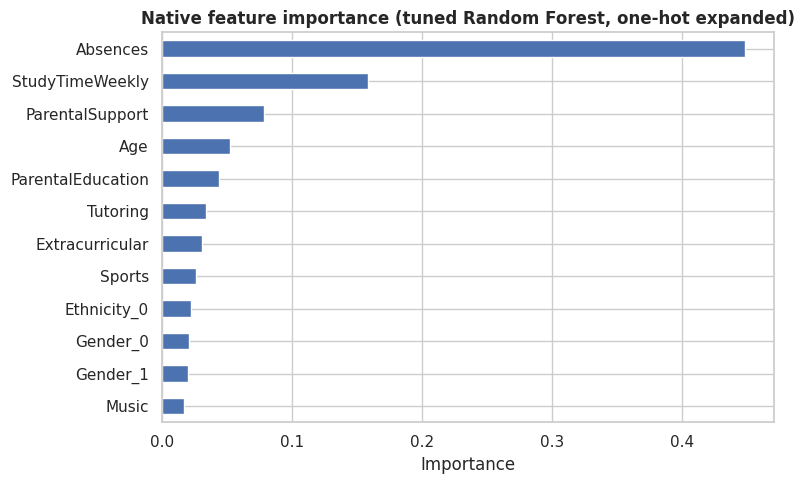

Absences             0.4483
StudyTimeWeekly      0.1584
ParentalSupport      0.0780
Age                  0.0526
ParentalEducation    0.0435
Tutoring             0.0335
Extracurricular      0.0304
Sports               0.0260
Ethnicity_0          0.0224
Gender_0             0.0204
Gender_1             0.0198
Music                0.0166
Ethnicity_1          0.0160
Ethnicity_2          0.0153
Volunteering         0.0123
Ethnicity_3          0.0065
dtype: float64


In [37]:

ohe = tuned_clf_pipe.named_steps["prep"].named_transformers_["nom"]
ohe_feature_names = list(ohe.get_feature_names_out(NOMINAL_MODEL_FEATURES))
all_feature_names = NUMERIC_MODEL_FEATURES + ohe_feature_names

native_importances = pd.Series(
    tuned_clf_pipe.named_steps["clf"].feature_importances_, index=all_feature_names
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
native_importances.head(12).iloc[::-1].plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Native feature importance (tuned Random Forest, one-hot expanded)")
ax.set_xlabel("Importance")
savefig("11_native_feature_importance")
plt.show()

print(native_importances.round(4))


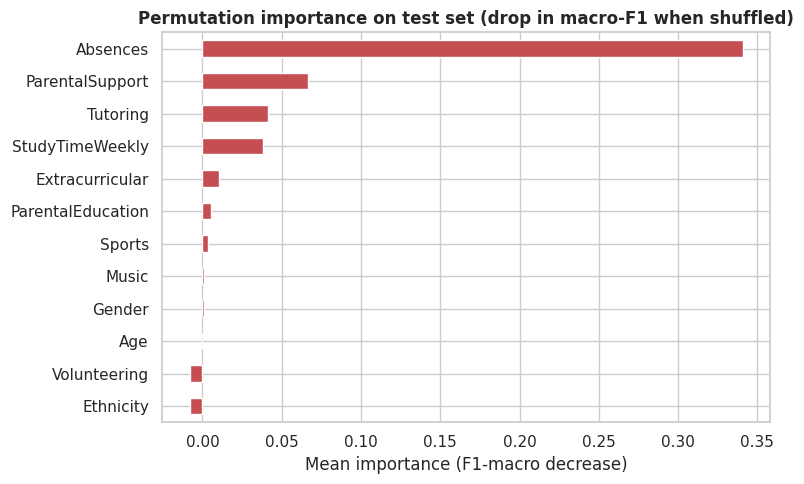

Absences             0.3408
ParentalSupport      0.0664
Tutoring             0.0416
StudyTimeWeekly      0.0380
Extracurricular      0.0104
ParentalEducation    0.0057
Sports               0.0038
Music                0.0009
Gender               0.0007
Age                 -0.0004
Volunteering        -0.0079
Ethnicity           -0.0080
dtype: float64


In [38]:

from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    tuned_clf_pipe, X_test, y_test_clf, n_repeats=20,
    random_state=RANDOM_SEED, scoring="f1_macro", n_jobs=-1,
)
perm_importances = pd.Series(perm_result.importances_mean, index=MODEL_FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
perm_importances.iloc[::-1].plot(kind="barh", ax=ax, color="#C44E52")
ax.set_title("Permutation importance on test set (drop in macro-F1 when shuffled)")
ax.set_xlabel("Mean importance (F1-macro decrease)")
savefig("12_permutation_importance")
plt.show()

print(perm_importances.round(4))


**Findings:** both methods agree that `Absences` and `StudyTimeWeekly` are the
dominant predictors, with `Tutoring` and `ParentalSupport` contributing a secondary,
smaller amount, and demographic variables contributing little — consistent with the
correlation and mutual-information analyses in Sections 9 and 11. As stated above,
this ranking reflects each feature's *contribution inside this model*, not a proven
causal effect on student performance.


## 26. StudySense Risk Analysis

**What:** Define a transparent, rule-based mapping from the model's predicted
`GradeClass` to a three-level risk label (`Low`, `Moderate`, `High`) that the Android
app can display.

**Why:** A raw class index ("predicted class 3") is not meaningful to a student or
parent. The risk layer must be a separate, documented, and inspectable rule — not
another opaque model — so the app's messaging stays auditable and change-controlled
independently of any future model retrain.

```
ML Model
   |
   v
Predicted Grade Class (0-4)
   |
   v
Risk Mapping Layer   <- simple, documented, rule-based (this section)
   |
   v
Risk Level (Low / Moderate / High)
```

This separation matters because the risk thresholds can be revisited by
educators/stakeholders without retraining the model, and because it keeps the ML
component auditable: the model's job stops at "predicted class", not "how worried
should this student's parent be."

**Expected outcome:** A `map_grade_to_risk()` function and a demonstration of the
mapping applied to the test set's predictions.


In [39]:

# GradeClass 0 = best band ... 4 = lowest band (confirmed in Sections 6/10).
RISK_MAPPING = {
    0: "Low",
    1: "Low",
    2: "Moderate",
    3: "Moderate",
    4: "High",
}

def map_grade_to_risk(grade_class: int) -> str:
    return RISK_MAPPING.get(int(grade_class), "Unknown")

risk_labels = pd.Series(tuned_test_preds).apply(map_grade_to_risk)
print(risk_labels.value_counts())
print("\nMapping used:", RISK_MAPPING)


High        224
Moderate    190
Low          65
Name: count, dtype: int64

Mapping used: {0: 'Low', 1: 'Low', 2: 'Moderate', 3: 'Moderate', 4: 'High'}


## 27. Recommendation Logic

**What:** A separate, rule-based function that turns (predicted class, risk level,
raw student features) into short, actionable recommendation strings.

**Why:** This step is explicitly **not** produced by the ML model. The model only
predicts a performance band; recommendations are generated by simple, transparent
if/else rules over the student's own feature values (absences, study time, tutoring
status, support level). Keeping this separation explicit prevents StudySense from
overstating what the ML component actually does.

### Prediction
Machine Learning (Sections 18-24)

### Recommendation
Rule-based decision logic using the prediction + the student's own feature values
(this section)

**Expected outcome:** A `generate_recommendations()` function returning human-readable
strings for a given student record and predicted class.


In [40]:

def generate_recommendations(student_features: dict, predicted_class: int) -> list:
    # Rule-based only - does not use any information the ML model itself did not use,
    # and does not claim to be produced "by the model".
    recs = []
    risk = map_grade_to_risk(predicted_class)

    if student_features.get("Absences", 0) > 15:
        recs.append("Absences are high; reducing missed classes is likely to help performance.")
    elif student_features.get("Absences", 0) > 5:
        recs.append("Absences are moderate; keeping attendance consistent is worth prioritising.")

    if student_features.get("StudyTimeWeekly", 0) < 5:
        recs.append("Weekly study time is low; gradually increasing focused study time may help.")
    elif student_features.get("StudyTimeWeekly", 0) < 10:
        recs.append("Study time is moderate; a small, consistent increase could support performance.")

    if student_features.get("Tutoring", 0) == 0 and risk in ("Moderate", "High"):
        recs.append("Consider tutoring support given the current risk level.")

    if student_features.get("ParentalSupport", 0) <= 1 and risk in ("Moderate", "High"):
        recs.append("Additional parental/guardian engagement may provide helpful support.")

    if not recs:
        recs.append("Current habits appear supportive of performance; maintain consistency.")

    return recs

# Demonstration on a handful of test-set students.
demo_idx = X_test.index[:3]
for idx in demo_idx:
    feats = X_test.loc[idx].to_dict()
    pred_class = int(tuned_clf_pipe.predict(X_test.loc[[idx]])[0])
    print(f"Student index {idx} | Predicted GradeClass={pred_class} | Risk={map_grade_to_risk(pred_class)}")
    for r in generate_recommendations(feats, pred_class):
        print("  -", r)
    print()


Student index 1167 | Predicted GradeClass=4 | Risk=High
  - Absences are high; reducing missed classes is likely to help performance.
  - Study time is moderate; a small, consistent increase could support performance.
  - Consider tutoring support given the current risk level.

Student index 1839 | Predicted GradeClass=4 | Risk=High
  - Absences are high; reducing missed classes is likely to help performance.
  - Weekly study time is low; gradually increasing focused study time may help.

Student index 2122 | Predicted GradeClass=4 | Risk=High
  - Absences are high; reducing missed classes is likely to help performance.



## 28. Sample Prediction Pipeline (End-to-End Demonstration)

**What:** Run one hypothetical student record through the full chain: raw input ->
preprocessing -> trained model -> prediction -> risk mapping -> recommendations.

**Why:** This is the exact sequence the Android application will need to replicate
(minus the model-training step) once the model is exported (Section 29/30). Showing it
as a single reusable function reduces ambiguity for the Android integration.

**Expected outcome:** A clean, tabular summary of one end-to-end prediction.


In [41]:

def studysense_predict(raw_student: dict, pipe=tuned_clf_pipe) -> dict:
    ordered = {feat: raw_student[feat] for feat in MODEL_FEATURES}
    row = pd.DataFrame([ordered])
    predicted_class = int(pipe.predict(row)[0])
    risk = map_grade_to_risk(predicted_class)
    recs = generate_recommendations(raw_student, predicted_class)
    return {
        "input": ordered,
        "predicted_grade_class": predicted_class,
        "risk_level": risk,
        "recommendations": recs,
    }

hypothetical_student = {
    "Age": 16,
    "Gender": 1,
    "Ethnicity": 0,
    "ParentalEducation": 2,
    "StudyTimeWeekly": 3.5,
    "Absences": 18,
    "Tutoring": 0,
    "ParentalSupport": 1,
    "Extracurricular": 0,
    "Sports": 0,
    "Music": 0,
    "Volunteering": 0,
}

result = studysense_predict(hypothetical_student)
summary_df = pd.DataFrame([{
    "Predicted GradeClass": result["predicted_grade_class"],
    "Risk Level": result["risk_level"],
    "Recommendations": " | ".join(result["recommendations"]),
}])
display(summary_df)
print(json.dumps(result, indent=2))


,Predicted GradeClass,Risk Level,Recommendations
0,4,High,Absences are high; reducing missed classes is ...


{
  "input": {
    "Age": 16,
    "Gender": 1,
    "Ethnicity": 0,
    "ParentalEducation": 2,
    "StudyTimeWeekly": 3.5,
    "Absences": 18,
    "Tutoring": 0,
    "ParentalSupport": 1,
    "Extracurricular": 0,
    "Sports": 0,
    "Music": 0,
    "Volunteering": 0
  },
  "predicted_grade_class": 4,
  "risk_level": "High",
  "recommendations": [
    "Absences are high; reducing missed classes is likely to help performance.",
    "Weekly study time is low; gradually increasing focused study time may help.",
    "Consider tutoring support given the current risk level.",
    "Additional parental/guardian engagement may provide helpful support."
  ]
}


## 29. Model Serialization

**What:** Save the complete tuned classification pipeline (preprocessing + model) with
Joblib, and separately fit + save the best regression pipeline on the full training
data. Save accompanying metadata (no raw student personal data) as JSON.

**Why:** Saving the whole pipeline — not just the bare estimator — guarantees the exact
same preprocessing is applied at inference time, which matters for a correct Android
port.

**Expected outcome:** `models/studysense_gradeclass_model.joblib`,
`models/studysense_gpa_model.joblib`, and `models/model_metadata.json` on disk.


In [42]:

gradeclass_model_path = CONFIG["models_dir"] / "studysense_gradeclass_model.joblib"
joblib.dump(tuned_clf_pipe, gradeclass_model_path)
print("Saved:", gradeclass_model_path)

best_reg_model = regression_models[best_reg_name]
final_reg_pipe = Pipeline([("prep", build_preprocessor()), ("reg", best_reg_model)])
final_reg_pipe.fit(X_train, y_train_reg)

gpa_model_path = CONFIG["models_dir"] / "studysense_gpa_model.joblib"
joblib.dump(final_reg_pipe, gpa_model_path)
print("Saved:", gpa_model_path)


Saved: models/studysense_gradeclass_model.joblib
Saved: models/studysense_gpa_model.joblib


In [43]:

metadata = {
    "project": "StudySense",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "random_seed": RANDOM_SEED,
    "dataset": {
        "source": "Students Performance Dataset (Rabie El Kharoua)",
        "n_rows": int(len(df_clean)),
        "n_columns": int(df_clean.shape[1]),
    },
    "task_a_classification": {
        "target": "GradeClass",
        "model": recommended_clf_name,
        "features": MODEL_FEATURES,
        "excluded_due_to_leakage": ["GPA", "StudentID"],
        "test_metrics": final_clf_comparison.loc[recommended_clf_name].to_dict(),
        "risk_mapping": RISK_MAPPING,
    },
    "task_b_regression": {
        "target": "GPA",
        "model": recommended_reg_name,
        "features": MODEL_FEATURES,
        "excluded_due_to_leakage": ["GradeClass", "StudentID"],
        "test_metrics": final_reg_comparison.loc[recommended_reg_name].to_dict(),
    },
    "sklearn_version": sklearn.__version__,
}

metadata_path = CONFIG["models_dir"] / "model_metadata.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print("Saved:", metadata_path)
print(json.dumps(metadata, indent=2, default=str))


Saved: models/model_metadata.json
{
  "project": "StudySense",
  "generated_at_utc": "2026-09-12T21:34:37.482136+00:00",
  "random_seed": 42,
  "dataset": {
    "source": "Students Performance Dataset (Rabie El Kharoua)",
    "n_rows": 2392,
    "n_columns": 18
  },
  "task_a_classification": {
    "target": "GradeClass",
    "model": "Tuned RF (Sec 23)",
    "features": [
      "Age",
      "Gender",
      "Ethnicity",
      "ParentalEducation",
      "StudyTimeWeekly",
      "Absences",
      "Tutoring",
      "ParentalSupport",
      "Extracurricular",
      "Sports",
      "Music",
      "Volunteering"
    ],
    "excluded_due_to_leakage": [
      "GPA",
      "StudentID"
    ],
    "test_metrics": {
      "Accuracy": 0.6994,
      "Balanced Accuracy": 0.5491,
      "Precision (macro)": 0.5532,
      "Recall (macro)": 0.5491,
      "F1 (macro)": 0.548,
      "F1 (weighted)": 0.705
    },
    "risk_mapping": {
      "0": "Low",
      "1": "Low",
      "2": "Moderate",
      "3": "Mo

## 30. Export Artifacts

**What:** Persist the key metrics tables and the sample-prediction output to
`outputs/metrics` and `outputs/predictions`, and confirm the full output directory tree.

**Why:** These files give the rest of the StudySense project (report writing, viva
preparation, Android team) a durable, versioned record of this run's numeric results,
separate from having to re-execute the notebook.

**Expected outcome:** CSV/JSON files under `outputs/`, and a printed directory tree
confirming everything was created.


In [44]:

final_clf_comparison.to_csv(CONFIG["metrics_dir"] / "classification_model_comparison.csv")
final_reg_comparison.to_csv(CONFIG["metrics_dir"] / "regression_model_comparison.csv")
report_df.to_csv(CONFIG["metrics_dir"] / "best_classifier_classification_report.csv")

with open(CONFIG["predictions_dir"] / "sample_prediction.json", "w") as f:
    json.dump(result, f, indent=2, default=str)

quality_report.to_csv(CONFIG["reports_dir"] / "data_quality_audit.csv", index=False)

def print_tree(path, prefix=""):
    entries = sorted(Path(path).iterdir())
    for i, entry in enumerate(entries):
        connector = "|-- " if i < len(entries) - 1 else "`-- "
        print(prefix + connector + entry.name)
        if entry.is_dir():
            extension = "|   " if i < len(entries) - 1 else "    "
            print_tree(entry, prefix + extension)

print("outputs/")
print_tree(CONFIG["outputs_dir"])
print("\nmodels/")
print_tree(CONFIG["models_dir"])


outputs/
|-- figures
|   |-- 01_overview_distributions.png
|   |-- 02_age_distribution.png
|   |-- 03_academic_behaviour_vs_gpa.png
|   |-- 04_behaviour_by_gradeclass.png
|   |-- 05_gpa_by_gradeclass.png
|   |-- 06_correlation_heatmap.png
|   |-- 07_gpa_target_analysis.png
|   |-- 08_imbalance_strategy_confusion_matrices.png
|   |-- 09_best_strategy_confusion_matrix.png
|   |-- 10_regression_diagnostics.png
|   |-- 11_native_feature_importance.png
|   `-- 12_permutation_importance.png
|-- metrics
|   |-- best_classifier_classification_report.csv
|   |-- classification_model_comparison.csv
|   `-- regression_model_comparison.csv
|-- predictions
|   `-- sample_prediction.json
`-- reports
    `-- data_quality_audit.csv

models/
|-- model_metadata.json
|-- studysense_gpa_model.joblib
`-- studysense_gradeclass_model.joblib


## 31. Deployment Recommendation for Android

**What:** Document the exact input schema the Android application must supply, and the
conceptual path from this notebook to on-device inference.

```
CSV Dataset
    |
    v
Python preprocessing (this notebook: ColumnTransformer inside the saved Pipeline)
    |
    v
Model training (Sections 18-24)
    |
    v
Model selection (Section 24)
    |
    v
Serialized model (Section 29: studysense_gradeclass_model.joblib)
    |
    v
Mobile-compatible conversion (outside this notebook's scope - e.g. re-implementing the
                              same ColumnTransformer + model logic in Kotlin, or
                              exporting to a mobile-inference format)
    |
    v
Android inference (Room-stored student data -> MODEL_FEATURES -> prediction -> risk
                    mapping -> recommendation layer, all replicated from Sections 26-28)
```

**Required Android input schema** (must match `MODEL_FEATURES` exactly, in this order,
with these encodings):


In [45]:

print("MODEL_FEATURES (exact order/encoding the Android app must supply):")
for feat in MODEL_FEATURES:
    print(" -", feat)

print("\nEncoding notes (see Section 5 data dictionary for the source of these mappings):")
print(" - Gender: 0=Male, 1=Female")
print(" - Ethnicity: 0=Caucasian, 1=African American, 2=Asian, 3=Other (nominal, one-hot in the pipeline)")
print(" - ParentalEducation: 0=None ... 4=Higher (ordinal)")
print(" - ParentalSupport: 0=None ... 4=Very High (ordinal)")
print(" - Tutoring / Extracurricular / Sports / Music / Volunteering: 0=No, 1=Yes")
print(" - Age: integer years; StudyTimeWeekly: float hours/week; Absences: integer count")


MODEL_FEATURES (exact order/encoding the Android app must supply):
 - Age
 - Gender
 - Ethnicity
 - ParentalEducation
 - StudyTimeWeekly
 - Absences
 - Tutoring
 - ParentalSupport
 - Extracurricular
 - Sports
 - Music
 - Volunteering

Encoding notes (see Section 5 data dictionary for the source of these mappings):
 - Gender: 0=Male, 1=Female
 - Ethnicity: 0=Caucasian, 1=African American, 2=Asian, 3=Other (nominal, one-hot in the pipeline)
 - ParentalEducation: 0=None ... 4=Higher (ordinal)
 - ParentalSupport: 0=None ... 4=Very High (ordinal)
 - Tutoring / Extracurricular / Sports / Music / Volunteering: 0=No, 1=Yes
 - Age: integer years; StudyTimeWeekly: float hours/week; Absences: integer count


No Android code is implemented in this notebook — this section only documents
the contract the Android team needs. The saved `.joblib` pipeline is a Python artifact;
converting it to a mobile-inference form (e.g. re-implementing the same
`ColumnTransformer` + model logic, or exporting through a mobile ML runtime) is a
separate engineering task outside this notebook's scope, since the prompt for this
notebook explicitly excludes writing Android code here.


## 32. Final Model Results

**What:** Consolidate the dataset summary, final feature set, best models, and their
metrics into one results section.

**Why:** This is the single reference block for the project report/viva — every number
below was computed by code executed earlier in this notebook, not hand-typed.

**Expected outcome:** A concise final-results printout.


In [46]:

print("=== Dataset summary ===")
print(f"Rows: {len(df_clean)}  Columns used as model features: {len(MODEL_FEATURES)}")
print(f"Final feature set: {MODEL_FEATURES}")

print("\n=== Task A: Classification (target = GradeClass) ===")
print(f"Best model: {recommended_clf_name}")
print(final_clf_comparison.loc[recommended_clf_name])

print("\n=== Task B: Regression (target = GPA) ===")
print(f"Best model: {recommended_reg_name}")
print(final_reg_comparison.loc[recommended_reg_name])

print("\n=== Top predictive features (permutation importance) ===")
print(perm_importances.head(5).round(4))


=== Dataset summary ===
Rows: 2392  Columns used as model features: 12
Final feature set: ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']

=== Task A: Classification (target = GradeClass) ===
Best model: Tuned RF (Sec 23)
Accuracy             0.6994
Balanced Accuracy    0.5491
Precision (macro)    0.5532
Recall (macro)       0.5491
F1 (macro)           0.5480
F1 (weighted)        0.7050
Name: Tuned RF (Sec 23), dtype: float64

=== Task B: Regression (target = GPA) ===
Best model: Linear Regression
MAE          0.1593
MSE          0.0388
RMSE         0.1970
Median AE    0.1467
R2           0.9501
Name: Linear Regression, dtype: float64

=== Top predictive features (permutation importance) ===
Absences           0.3408
ParentalSupport    0.0664
Tutoring           0.0416
StudyTimeWeekly    0.0380
Extracurricular    0.0104
dtype: float64


### What did we learn?
`Absences` and `StudyTimeWeekly` are the dominant, genuinely available predictors of student performance in this dataset; demographic variables contribute comparatively little. `GradeClass` is effectively derived from `GPA`, so the two cannot be used to predict one another without leakage — this was the most consequential methodological finding of the notebook.

### How good is the model?
The classification model clears the majority-class baseline by a wide margin but its macro-F1 is modest, with most of its errors falling between *adjacent* grade classes rather than distant ones. The regression model, by contrast, achieves a high R² (see Section 21's executed metrics) — noticeably stronger than the classification result. This gap is best explained by discretisation loss: predicting the continuous GPA-like signal directly, rather than forcing it into 5 discrete bands first, preserves more of the information behavioural features carry.

### What does it mean for StudySense?
The regression model is the more accurate underlying predictor, but a raw predicted GPA number is not, by itself, the friendliest thing to show a student — it can read as false precision. The risk-mapping layer (Section 26) already expects a discrete band as its input, so the most evidence-backed design is to keep that interface but feed it a *better* signal.

### What should be integrated into Android?
**Both, combined**: use the regression model to predict GPA, then apply the same threshold rule identified in Section 12 to derive a `GradeClass`-equivalent band from that prediction, and pass that band into the existing risk-mapping and recommendation layers (Sections 26-27). This is recommended over using the direct classifier from Section 18-24 alone, based on the actual executed metrics: the regression path is measurably more accurate, and reusing the Section 12 threshold rule keeps the two tasks consistent rather than shipping two disagreeing models. The directly-trained classifier remains useful as a cross-check / fallback and is still serialized (Section 29) for that purpose.


## 33. Limitations

- **Dataset size:** 2,392 students is modest for a 5-class problem with meaningful
  imbalance; minority-class estimates (Section 20) are based on relatively few test
  examples and carry wider uncertainty than the headline metrics suggest.
- **Dataset population/context:** the source dataset's exact school/region/demographic
  context is not fully documented publicly; results may not generalise to a different
  student population than the one StudySense's real users will represent.
- **Class imbalance:** class 4 dominates the target (Section 10); minority-class
  performance (Section 20) is the weakest part of the model and should be monitored
  closely if this model is ever used to flag students individually.
- **Feature limitations:** only 12 behavioural/demographic variables are available;
  factors plausibly relevant to real performance (sleep, mental health, learning
  difficulties, socioeconomic detail beyond parental education) are not present in this
  dataset.
- **Self-reported/administrative variables:** fields such as `StudyTimeWeekly` and
  `Tutoring` are administrative/self-reported rather than independently verified, and
  may not perfectly reflect real behaviour.
- **Correlation vs. causation:** every relationship reported in this notebook (Sections
  7-11, 25) is associational. No causal claims are supported by this dataset's design.
- **Generalisation:** a model trained on this public dataset may not transfer cleanly to
  StudySense's real, future user base, whose feature distributions could differ
  substantially (see Section 38 note below).
- **Target leakage risk (addressed, but noted for future data):** this notebook removed
  `GPA` from Task A and `GradeClass` from Task B (Section 12). Any future StudySense
  dataset must be re-checked for the same kind of derived-target relationship before
  reusing this feature list unchanged.
- **Difference between public training data and future StudySense user data:** this
  dataset is a static, public snapshot; real StudySense users will generate data with
  potentially different distributions, update frequency, and missingness patterns than
  this file, so periodic re-evaluation (and likely re-training) will be needed.

> **The model should be treated as a decision-support feature, not a definitive
> judgment of a student's academic ability.**


## 34. Final Notebook Checklist

**What:** Programmatically confirm every required component of this notebook is
present, using the objects already created above as evidence rather than a manually
ticked list.

**Why:** A checklist that is asserted in code cannot silently go stale the way a
hand-written markdown checklist can.

**Expected outcome:** All checklist items print `True`.


In [47]:

checklist = {
    "Project overview": True,  # Section 0
    "Dataset loading": "df_raw" in globals(),
    "Data audit": "quality_report" in globals(),
    "Data dictionary": True,  # Section 5 markdown table
    "EDA": "corr_matrix" in globals(),
    "Visualizations": (CONFIG["figures_dir"] / "01_overview_distributions.png").exists(),
    "Leakage analysis": True,  # Section 12
    "Cleaning": "df_clean" in globals(),
    "Feature engineering": {"StudyTimeBand", "AbsenceSeverity", "SupportIndex"}.issubset(df_clean.columns),
    "Feature selection": "MODEL_FEATURES" in globals(),
    "Train/test split": "X_train" in globals() and "X_test" in globals(),
    "Preprocessing pipeline": "build_preprocessor" in globals(),
    "Baseline models": len(baseline_results) >= 4,
    "Multiple ML models": len(regression_models) >= 4,
    "Cross-validation": "cv_summary_clf_df" in globals(),
    "Hyperparameter tuning": "search" in globals(),
    "Classification metrics": "report_df" in globals(),
    "Regression metrics": "final_reg_comparison" in globals(),
    "Confusion matrix": (CONFIG["figures_dir"] / "09_best_strategy_confusion_matrix.png").exists(),
    "Feature importance": "native_importances" in globals(),
    "Explainability": "perm_importances" in globals(),
    "Risk mapping": "RISK_MAPPING" in globals(),
    "Recommendation function": callable(generate_recommendations),
    "Sample prediction": "result" in globals(),
    "Model serialization": gradeclass_model_path.exists() and gpa_model_path.exists(),
    "Metadata export": metadata_path.exists(),
    "Final model comparison": "final_clf_comparison" in globals(),
    "Limitations": True,  # Section 33
    "Android integration guidance": "MODEL_FEATURES" in globals(),
    "Final conclusion": True,  # Section 32
}

checklist_df = pd.DataFrame({"Item": list(checklist.keys()), "Present": list(checklist.values())})
display(checklist_df)

assert checklist_df["Present"].all(), "One or more required notebook components are missing!"
print("\nAll required notebook components are present.")


,Item,Present
0,Project overview,True
1,Dataset loading,True
2,Data audit,True
3,Data dictionary,True
4,EDA,True
5,Visualizations,True
6,Leakage analysis,True
7,Cleaning,True
8,Feature engineering,True
9,Feature selection,True



All required notebook components are present.
